In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import matplotlib
print(matplotlib.get_backend())

module://matplotlib_inline.backend_inline


In [3]:
pd.options.plotting.backend = "matplotlib" 
#pd.options.plotting.backend = "plotly"
#pd.options.plotting.backend = "hvplot"

In [4]:
#%matplotlib notebook
#%matplotlib inline

In [5]:
import seaborn as sns

In [6]:
###dat = pd.read_csv('../../Projects/TTD/bq-results-20251212-union.csv', low_memory=False).replace(' ', None)
###dat = pd.read_csv('../../Projects/TTD/bq-results-20251219-union.csv', low_memory=False).replace(' ', None)
dat = pd.read_csv('../../Projects/TTD/bq-results-20251220-union.csv', low_memory=False).replace(' ', None)

In [7]:
dat.shape

(46217, 20)

In [8]:
def get_geo(litems):
    check = ['Asia', 'US', 'Global', 'APAC']
    for c in check:
        if c in litems:
            return c
    return 'Unknown'

In [9]:
dat['geo'] = dat.Full_Path.apply(lambda x: get_geo(x.replace(" ", "").split(">")))

In [10]:
dat.groupby('geo').size()

geo
APAC          96
Asia        9818
Global     25338
US          6656
Unknown     4309
dtype: int64

In [11]:
dat.head()

,Week_Start_Date,Full_Path,Advertiser_Category,Third_Party_Data_Provider_Id,Third_Party_Data_Sub_Provider_Id,Received_ID_Count,Active_ID_Count,Active_ID_Count_Percentile,Effective_Impression_Count,Data_Cost,...,Selected_Pct_Percentile,Avg_Relevance,Avg_Relevance_Percentile,Avg_Value_Score,Avg_Value_Percentile,Match_Pct,Match_Pct_Percentile,Paid_Pct,Paid_Pct_Percentile,geo
0,2025-10-20 00:00:00 UTC,Data Alliance > Retail > Interest > Global > M...,All,dav2shreths,None,469500300.0,223662800.0,97.0,210.0,0.00,...,56.8,4.2,80.9,61.0,94.6,0.0000,59.6,10.7,64.5,Global
1,2025-10-20 00:00:00 UTC,Data Alliance > Automotive > Interest > Global...,All,dav2shreths,None,NaN,NaN,NaN,NaN,NaN,...,NaN,4.4,84.9,NaN,NaN,NaN,NaN,NaN,NaN,Global
2,2025-10-20 00:00:00 UTC,Data Alliance > Business & Finance > Interest ...,All,dav2shreths,None,327039700.0,164794400.0,96.0,583411.0,31.85,...,84.7,4.4,83.9,61.0,94.6,0.0017,97.1,99.9,90.8,Global
3,2025-10-20 00:00:00 UTC,Data Alliance > Food & Beverages > Interest > ...,All,dav2shreths,None,354196300.0,177782000.0,96.3,155.0,0.00,...,56.8,4.4,83.6,61.0,94.6,0.0000,59.6,100.0,91.8,Global
4,2025-10-20 00:00:00 UTC,Data Alliance > CPG > Interest > Global > Food...,All,dav2shreths,None,NaN,NaN,NaN,NaN,NaN,...,NaN,4.5,86.0,NaN,NaN,NaN,NaN,NaN,NaN,Global


In [12]:
dat['Clean_Path'] = dat.Full_Path.apply(lambda x: x.lower().replace(" ", ""))

array([[<Axes: title={'center': 'Received_ID_Count'}>]], dtype=object)

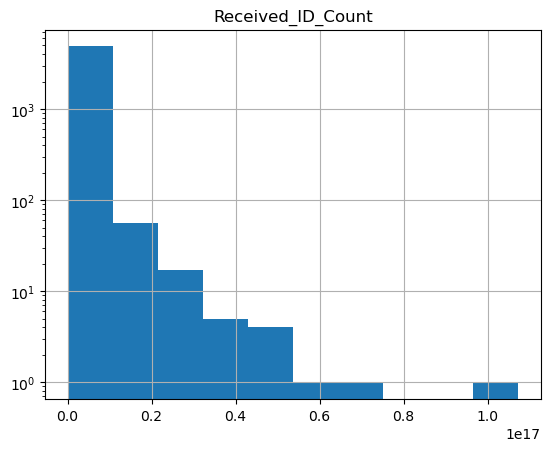

In [13]:
dat.groupby('Clean_Path')[['Received_ID_Count']].var().hist(log=True)

In [14]:
dat['segment_last'] = dat.Clean_Path.apply(lambda x: x.split(">")[-1].replace("age", ""))
dat['segment_1'] = dat.Clean_Path.apply(lambda x: x.split(">")[0])
##dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['segment_2'] = dat.Clean_Path.apply(lambda x: x.replace("otp>", "").split(">")[1] if len(x.split(">")) > 1 else "N/A")
dat['week_start'] = dat.Week_Start_Date.apply(lambda x: x.split(" ")[0])

In [15]:
dat.groupby('Third_Party_Data_Provider_Id')['segment_last'].unique()

Third_Party_Data_Provider_Id
dav2shreths    [sportstv, x4, businessnews, desserts, condime...
sharethis      [flash-basedentertainment, multilateralorganiz...
Name: segment_last, dtype: object

In [16]:
#seg_last_vb = list(dat[dat.Third_Party_Data_Provider_Id == 'sharethis']['segment_last'].unique())
#seg_last_da = list(dat[dat.Third_Party_Data_Provider_Id == 'dav2shreths']['segment_last'].unique())

In [17]:
seg_last_vb = pd.DataFrame(dat[dat.Third_Party_Data_Provider_Id == 'sharethis']['segment_last'].value_counts())
seg_last_da = pd.DataFrame(dat[dat.Third_Party_Data_Provider_Id == 'dav2shreths']['segment_last'].value_counts())

In [18]:
seg_last_vb.describe()

,count
count,1724.000000
mean,16.812065
std,8.127221
min,2.000000
25%,8.000000
50%,16.000000
75%,24.000000
max,72.000000


In [19]:
seg_last_da.describe()

,count
count,1776.000000
mean,9.703266
std,7.803380
min,2.000000
25%,8.000000
50%,8.000000
75%,8.000000
max,272.000000


In [20]:
len(set(dat['segment_last']))

3214

In [21]:
def find_common_substrings(list1, list2, fuzzy_only=True):
    """
    Finds all strings from list1 that are substrings of any string in list2.
    """
    common_subs = set()
    matches = []
    exact_matches = set()
    for s1 in list1:
        for s2 in list2:
            if s1 == s2:
                exact_matches.add(s1)
                if fuzzy_only:
                    continue
            if len(s1) > 2 and s1.lower() in s2.lower():
                common_subs.add(s1.lower())
                matches.append([s1, s2])
            elif len(s2) > 2 and s2.lower() in s1.lower():
                common_subs.add(s2.lower())
                matches.append([s1, s2])
    return list(common_subs), matches, exact_matches

In [22]:
seg_common, matches, exact_matches = find_common_substrings(seg_last_vb[seg_last_vb["count"] > 1].index, 
                                             seg_last_da[seg_last_da["count"] > 1].index)
len(seg_common)

509

In [23]:
#matches

In [24]:
#exact_matches

In [25]:
#for k in exact_matches:
#    print (k, seg_last_vb.loc[k].values[0], seg_last_da.loc[k].values[0])

In [26]:
dat.tail()

,Week_Start_Date,Full_Path,Advertiser_Category,Third_Party_Data_Provider_Id,Third_Party_Data_Sub_Provider_Id,Received_ID_Count,Active_ID_Count,Active_ID_Count_Percentile,Effective_Impression_Count,Data_Cost,...,Match_Pct,Match_Pct_Percentile,Paid_Pct,Paid_Pct_Percentile,geo,Clean_Path,segment_last,segment_1,segment_2,week_start
46212,2025-12-08 00:00:00 UTC,OTP > US > Demographic > Age > Age 50-54,All,sharethis,None,274977400.0,105831900.0,95.0,176009.0,11.13,...,0.0005,94.8,92.0,89.7,US,otp>us>demographic>age>age50-54,50-54,otp,demographic,2025-12-08
46213,2025-12-08 00:00:00 UTC,OTP > US > Demographic > Age > Age 55-64,All,sharethis,None,277022900.0,106346800.0,95.0,678485.0,21.71,...,0.0062,99.2,29.8,72.5,US,otp>us>demographic>age>age55-64,55-64,otp,demographic,2025-12-08
46214,2025-12-08 00:00:00 UTC,OTP > US > Demographic > Age > Age 65+,All,sharethis,None,275585400.0,105983900.0,95.0,210512.0,1.53,...,0.0019,97.9,29.5,72.4,US,otp>us>demographic>age>age65+,65+,otp,demographic,2025-12-08
46215,2025-12-08 00:00:00 UTC,OTP > US > Demographic > Gender > Female,All,sharethis,None,274831700.0,105780800.0,95.0,20933080.0,537.38,...,0.1932,100.0,29.5,72.4,US,otp>us>demographic>gender>female,female,otp,demographic,2025-12-08
46216,2025-12-08 00:00:00 UTC,OTP > US > Demographic > Gender > Male,All,sharethis,None,273176500.0,104736500.0,95.0,28947478.0,322.63,...,0.1296,100.0,60.7,78.7,US,otp>us>demographic>gender>male,male,otp,demographic,2025-12-08


In [27]:
len(dat['segment_last'].unique()), len(dat['segment_1'].unique()), len(dat['segment_2'].unique())

(3214, 11, 90)

In [28]:
dat.groupby(['Third_Party_Data_Provider_Id','segment_last']).size()

Third_Party_Data_Provider_Id  segment_last                
dav2shreths                   1-3months                        8
                              1-star                           8
                              10+vehicles                      8
                              1500                             8
                              18-20                            8
                                                              ..
sharethis                     yoga&pilates                    24
                              yogurt                           8
                              youthorganizations&resources    10
                              zeroproof                        8
                              zoos-aquariums-preserves        24
Length: 3500, dtype: int64

In [29]:
dat.groupby(['Third_Party_Data_Provider_Id','segment_last']).size().groupby('Third_Party_Data_Provider_Id').size()

Third_Party_Data_Provider_Id
dav2shreths    1776
sharethis      1724
dtype: int64

In [30]:
dat.groupby(['geo','segment_last']).size().groupby('geo').size()

geo
APAC         12
Asia       1173
Global     2579
US          825
Unknown     462
dtype: int64

In [31]:
dat['segment_1'].unique()

array(['dataalliance', 'asia', 'political', 'intent', 'us', 'b2b', 'otp',
       'interestfromsocialactivity', 'global', 'winterholiday',
       'unavailable'], dtype=object)

In [32]:
#seg1 = 'otp'
#dat[dat.segment_1 == seg1]['Full_Path'].values[-10:]

#otp -> 3rd & last
#b2b -> 2nd & last
#datalliance -> 2nd & last
# interestfromsocialactivity -> last
# global -> 2nd & last
# us -> last (or 3rd?)
# politcal -> last
# intent -> 2nd & last?
# winterholiday -> last or 2nd
# asian -> 2nd & last?

In [33]:
dat['segment_2'].unique()

array(['retail', 'automotive', 'business&finance', 'food&beverages',
       'cpg', 'education', 'health&wellness', 'technology&computing',
       'sports', 'demographic', 'shopping', 'realestate', 'travel',
       'hobbies&interests', 'books&literature', 'arts&entertainment',
       'pets&animals', 'games&gaming', 'news&politics', 'home&garden',
       'lifestyle&living', 'style&fashion', 'career&jobs',
       'law&government', 'computers&electronics', 'politician',
       'business&industrial', 'internet&telecom', 'people&society',
       'seasonal', 'games', 'news', 'autos&vehicles', 'onlinecommunities',
       'food&drink', 'finance', 'thechangingconsumer', 'jobs&education',
       'lifeevent', 'hobbies&leisure', 'beauty&fitness', 'science',
       'dataforgood', 'reference', 'intent', 'validateddemographic',
       'industry', 'autobuyers', 'sentiment', 'occupation',
       'functionalarea', 'health', 'professionalgroups', 'seniority',
       'companysize', 'moviegoers', 'publicfig

In [34]:
dat.groupby('geo').size()

geo
APAC          96
Asia        9818
Global     25338
US          6656
Unknown     4309
dtype: int64

# EDA

In [35]:
dat1 = dat[dat.Received_ID_Count.isna() == False]
dat1 = dat1[dat1.Advertiser_Category == 'All']           
dat1.shape

(34125, 26)

In [36]:
dat1['Received_ID_Count'] = dat1['Received_ID_Count'].astype(int)
dat1['Active_ID_Count'] = dat1['Active_ID_Count'].astype(int)
dat1['Effective_Impression_Count'] = dat1['Effective_Impression_Count'].astype(int)

In [37]:
dat['Data_Cost'] = dat['Data_Cost'].astype(float)
dat1['Match_Pct'] = dat1['Match_Pct'].astype(float)
dat1['Match_Pct_Percentile'] = dat1['Match_Pct_Percentile'].astype(float)

In [38]:
dat1_sample = dat1.sample(1000)
dat1_sample.head()

,Week_Start_Date,Full_Path,Advertiser_Category,Third_Party_Data_Provider_Id,Third_Party_Data_Sub_Provider_Id,Received_ID_Count,Active_ID_Count,Active_ID_Count_Percentile,Effective_Impression_Count,Data_Cost,...,Match_Pct,Match_Pct_Percentile,Paid_Pct,Paid_Pct_Percentile,geo,Clean_Path,segment_last,segment_1,segment_2,week_start
29141,2025-11-24 00:00:00 UTC,Data Alliance > Business & Finance > Interest ...,All,dav2shreths,None,14976200,8152600,84.9,26023,0.61,...,0.0002,91.0,31.0,68.3,Global,dataalliance>business&finance>interest>global>...,businessloans,dataalliance,business&finance,2025-11-24
24047,2025-11-17 00:00:00 UTC,Data Alliance > CPG > Interest > Global > Heal...,All,dav2shreths,None,100562500,53065600,91.6,4597,0.46,...,0.0001,85.6,19.0,65.6,Global,dataalliance>cpg>interest>global>health&wellne...,menshaving,dataalliance,cpg,2025-11-17
13467,2025-11-03 00:00:00 UTC,Data Alliance > Health & Wellness > Interest >...,All,dav2shreths,None,24524800,13816700,85.5,105,0.00,...,0.0000,59.3,67.7,75.1,Global,dataalliance>health&wellness>interest>global>p...,nailpolish,dataalliance,health&wellness,2025-11-03
18555,2025-11-10 00:00:00 UTC,Data Alliance > Home & Garden > Interest > Glo...,All,dav2shreths,None,29736800,16390000,86.2,100751,0.66,...,0.0003,92.1,91.7,82.7,Global,dataalliance>home&garden>interest>global>homei...,housewares,dataalliance,home&garden,2025-11-10
32165,2025-11-24 00:00:00 UTC,US > Data for Good > Social Issues & Advocacy,All,sharethis,None,441046300,219874300,97.3,2831,0.09,...,0.0000,60.8,98.7,88.4,US,us>dataforgood>socialissues&advocacy,socialissues&advocacy,us,dataforgood,2025-11-24


In [39]:
dat1_sample['revenue_per_user'] = dat1_sample['Data_Cost'] / dat1_sample['Received_ID_Count']
dat1_sample['revenue_per_active_user'] = dat1_sample['Data_Cost'] / dat1_sample['Active_ID_Count']

In [40]:
dat1_sample['ecpm'] = dat1_sample['Data_Cost'] / dat1_sample['Effective_Impression_Count']

<Axes: title={'center': 'number of segments'}, xlabel='week_start'>

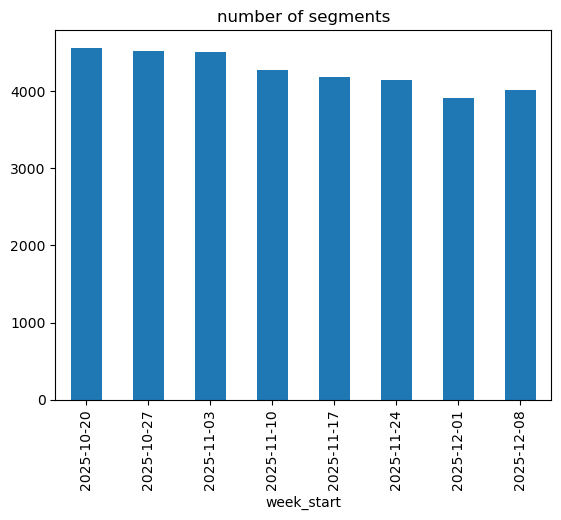

In [41]:
dat1.groupby('week_start').size().plot(kind='bar', title='number of segments')

In [42]:
def get_split_means(dat1_sample, value = 'Avg_Relevance'):
    return dat1_sample.groupby(['week_start', 'Third_Party_Data_Provider_Id'])[[value]].mean().pivot_table(
    index='week_start', columns='Third_Party_Data_Provider_Id', values=value)

def get_split_plots(dat1_sample, x, y, kind='scatter', logx=False, logy=False):
    ax=None
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id == 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='branded taxonomy', color='green')
    ax=dat1_sample[dat1_sample.Third_Party_Data_Provider_Id != 'sharethis'].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label='data alliance', color='orange')
    return ax

from matplotlib.pyplot import cm
def get_split_plots2(dat1_sample, x, y, kind='scatter', by='geo', logx=False, logy=False, alpha=1):
    ax=None
    vals = set(dat1_sample[by].values)
    color = cm.rainbow(np.linspace(0, 1, len(vals)))
    for i, val in enumerate(vals):
        ax=dat1_sample[dat1_sample[by] == val].plot(ax=ax, kind=kind, x=x, y=y, logx=logx, logy=logy, label=val, color=color[i], alpha=alpha)
    return ax

In [43]:
get_split_means(dat1_sample, value = 'Avg_Relevance')

Third_Party_Data_Provider_Id,dav2shreths,sharethis
week_start,,
2025-10-20,4.872500,3.788172
2025-10-27,4.994118,3.619767
2025-11-03,5.108696,3.861111
2025-11-10,4.839394,4.000000
2025-11-17,4.872500,3.359615
2025-11-24,5.560606,4.088372
2025-12-01,5.702381,4.411392
2025-12-08,5.961364,4.225301


In [44]:
get_split_means(dat1_sample, value = 'Data_Cost')

Third_Party_Data_Provider_Id,dav2shreths,sharethis
week_start,,
2025-10-20,2.365250,7.352688
2025-10-27,7.409706,8.797326
2025-11-03,4.933043,11.029583
2025-11-10,14.233030,17.255059
2025-11-17,2.492000,12.962788
2025-11-24,19.872424,10.686395
2025-12-01,16.552857,6.681139
2025-12-08,6.730455,8.686747


<Axes: title={'center': 'avg(relevance) over time'}, xlabel='week_start', ylabel='relevance'>

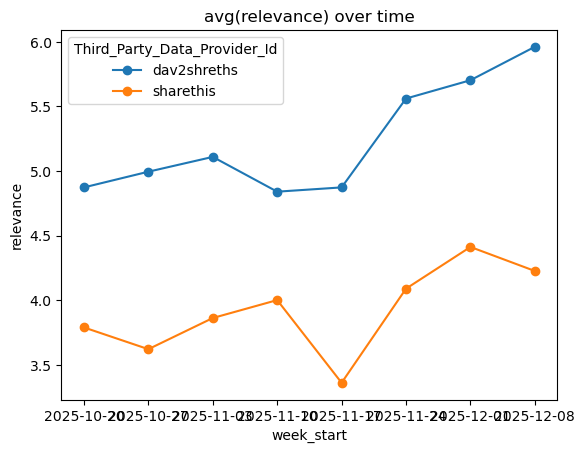

In [45]:
get_split_means(dat1_sample, value = 'Avg_Relevance').plot(marker='o', title='avg(relevance) over time', ylabel='relevance')

<Axes: title={'center': 'avg(revenue) over time'}, xlabel='week_start', ylabel='revenue'>

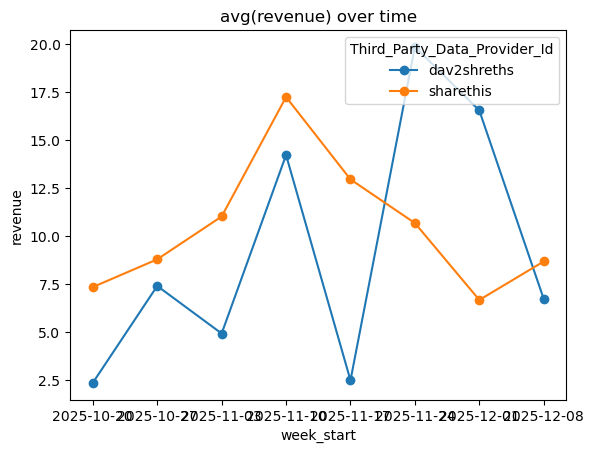

In [46]:
get_split_means(dat1_sample, value = 'Data_Cost').plot(marker='o', title='avg(revenue) over time', ylabel='revenue')

In [47]:
dat1[['Data_Cost', 'Avg_Relevance', 'Avg_Relevance_Percentile']].corr()

,Data_Cost,Avg_Relevance,Avg_Relevance_Percentile
Data_Cost,1.000000,0.011633,0.013364
Avg_Relevance,0.011633,1.000000,0.949020
Avg_Relevance_Percentile,0.013364,0.949020,1.000000


<Axes: xlabel='week_start'>

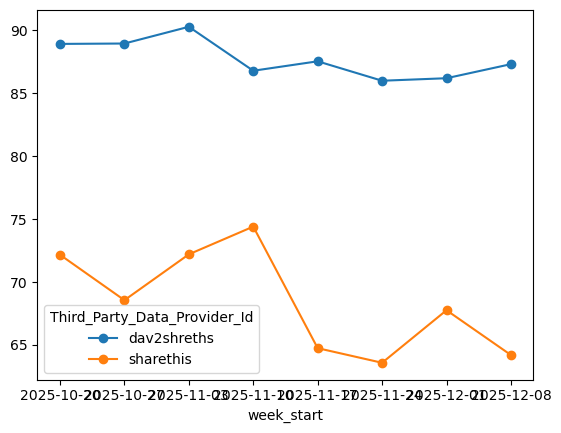

In [48]:
get_split_means(dat1_sample, value = 'Avg_Relevance_Percentile').plot(marker='o')

<Axes: xlabel='Received_ID_Count', ylabel='Active_ID_Count'>

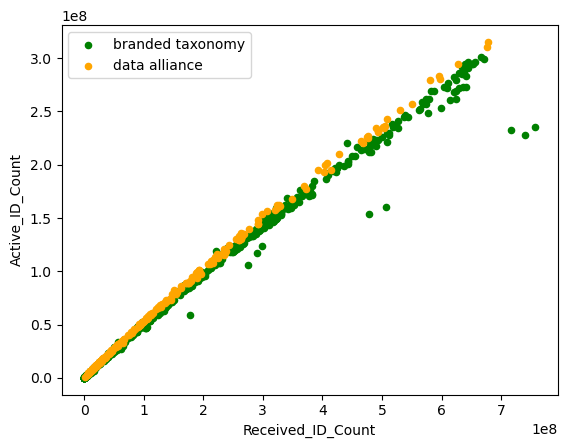

In [49]:
get_split_plots(dat1_sample, x='Received_ID_Count', y='Active_ID_Count')
#get_split_plots2(dat1_sample, x='Received_ID_Count', y='Active_ID_Count', by='geo')

<Axes: >

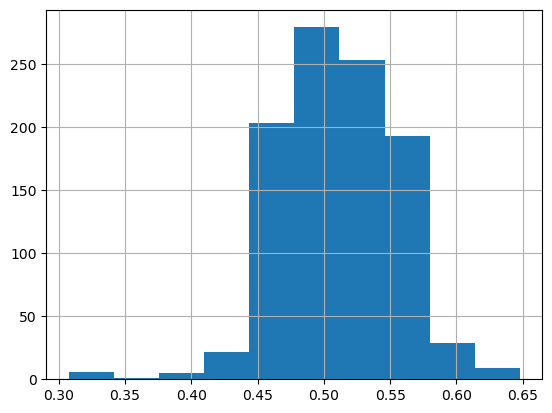

In [50]:
(dat1_sample['Active_ID_Count'] / dat1_sample['Received_ID_Count']).hist()

In [51]:
(dat1_sample['Active_ID_Count'] / dat1_sample['Received_ID_Count']).mean()

0.5103851603380212

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Received_ID_Count', ylabel='Effective_Impression_Count'>

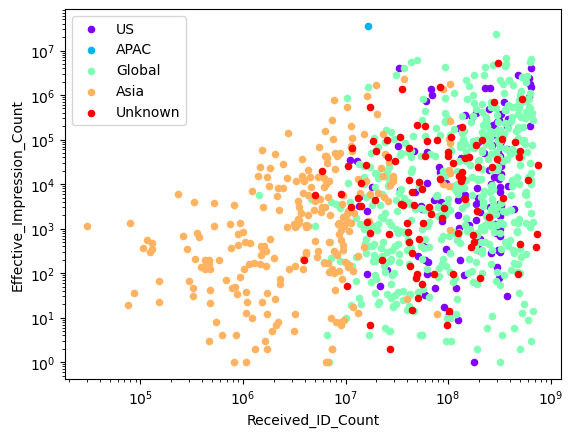

In [52]:
#get_split_plots(dat1_sample, x='Received_ID_Count', y='Effective_Impression_Count', logy=True, logx=True)
get_split_plots2(dat1_sample, x='Received_ID_Count', y='Effective_Impression_Count', by='geo', logy=True, logx=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Received_ID_Count', ylabel='Effective_Impression_Count'>

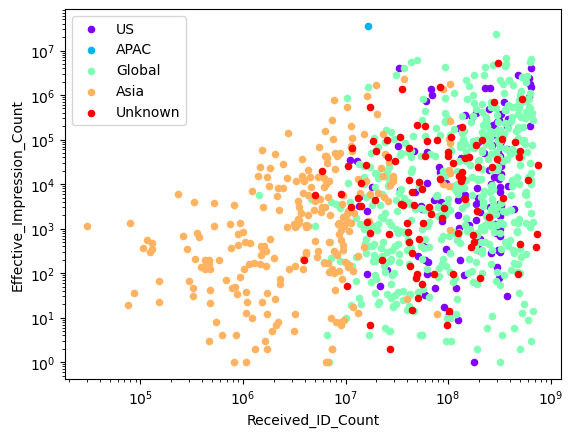

In [52]:
#get_split_plots(dat1_sample, x='Received_ID_Count', y='Effective_Impression_Count', logy=True, logx=True)
get_split_plots2(dat1_sample, x='Received_ID_Count', y='Effective_Impression_Count', by='geo', logy=True, logx=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Active_ID_Count', ylabel='Effective_Impression_Count'>

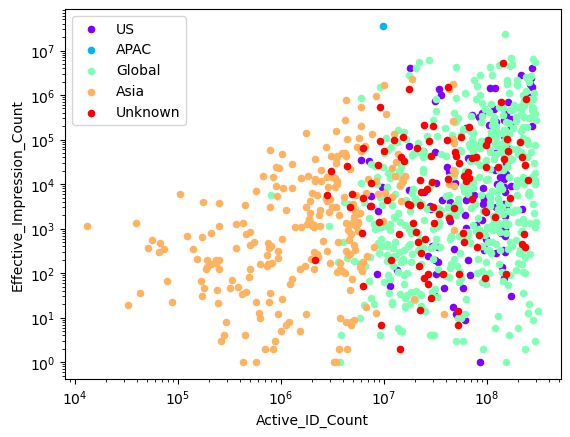

In [53]:
#get_split_plots(dat1_sample, x='Active_ID_Count', y='Effective_Impression_Count', logy=True, logx=True)
get_split_plots2(dat1_sample, x='Active_ID_Count', y='Effective_Impression_Count', by='geo', logy=True, logx=True)

<Axes: xlabel='Avg_Relevance', ylabel='Effective_Impression_Count'>

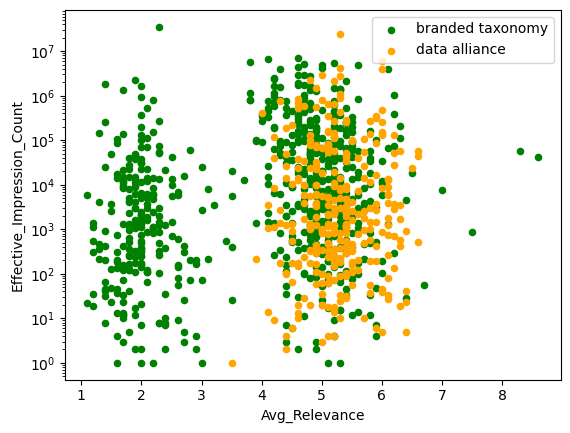

In [54]:
get_split_plots(dat1_sample, x='Avg_Relevance', y='Effective_Impression_Count', logy=True, logx=False)

<Axes: xlabel='Effective_Impression_Count', ylabel='Data_Cost'>

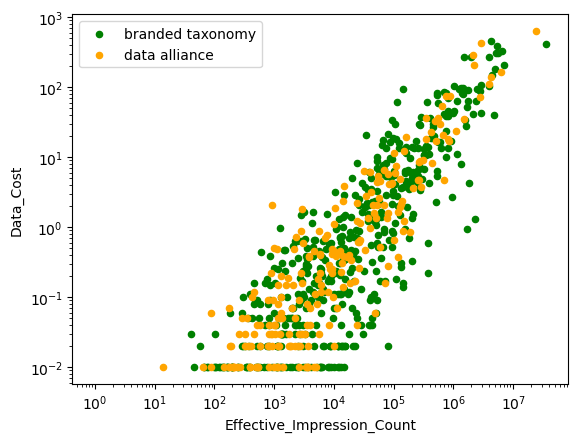

In [55]:
get_split_plots(dat1_sample, y='Data_Cost', x='Effective_Impression_Count', logy=True, logx=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Received_ID_Count', ylabel='Avg_Relevance'>

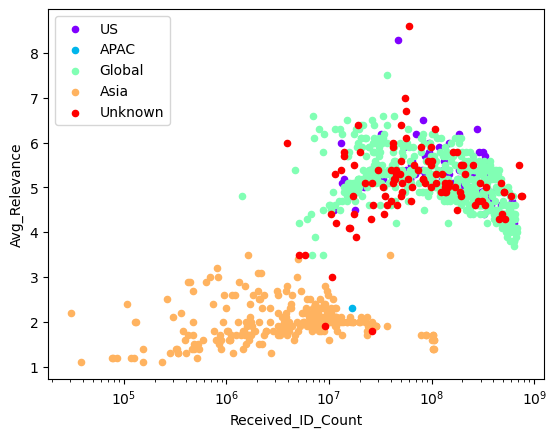

In [56]:
get_split_plots2(dat1_sample, y='Avg_Relevance', x='Received_ID_Count', by='geo', logy=False, logx=True)

<Axes: xlabel='Received_ID_Count', ylabel='Match_Pct'>

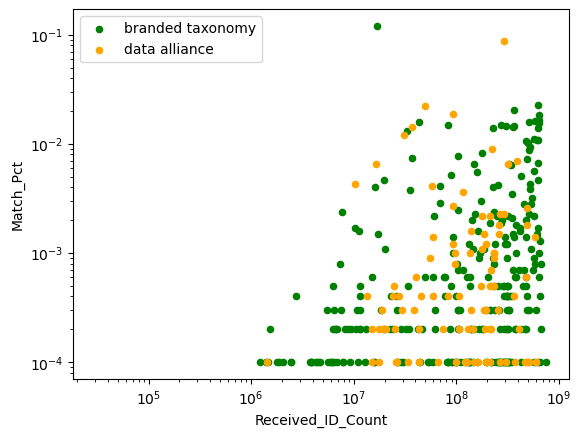

In [57]:
get_split_plots(dat1_sample, y='Match_Pct', x='Received_ID_Count', logy=True, logx=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Received_ID_Count', ylabel='Data_Cost'>

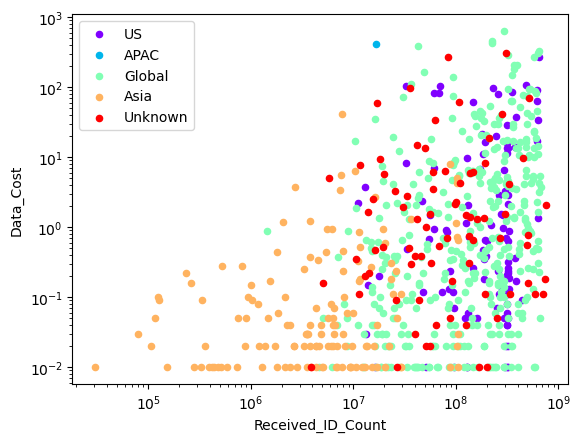

In [58]:
get_split_plots2(dat1_sample, x='Received_ID_Count', y='Data_Cost', kind='scatter', by='geo', logx=True, logy=True)

<Axes: xlabel='Avg_Relevance', ylabel='revenue_per_user'>

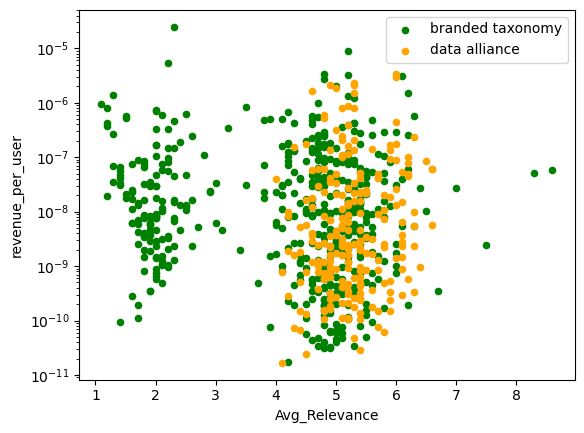

In [59]:
get_split_plots(dat1_sample, y='revenue_per_user', x='Avg_Relevance', logy=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Avg_Relevance', ylabel='revenue_per_user'>

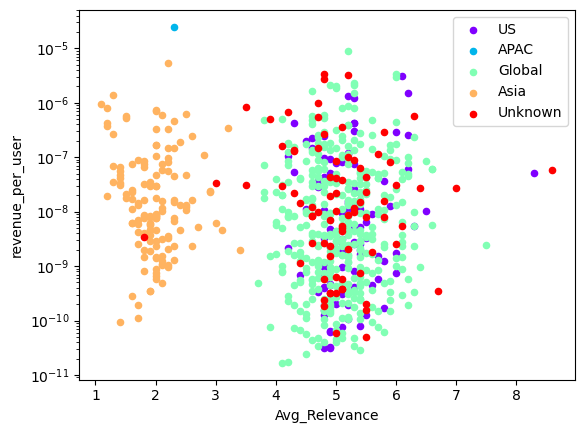

In [60]:
get_split_plots2(dat1_sample, x='Avg_Relevance', y='revenue_per_user', kind='scatter', by='geo', logx=False, logy=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Received_ID_Count', ylabel='revenue_per_user'>

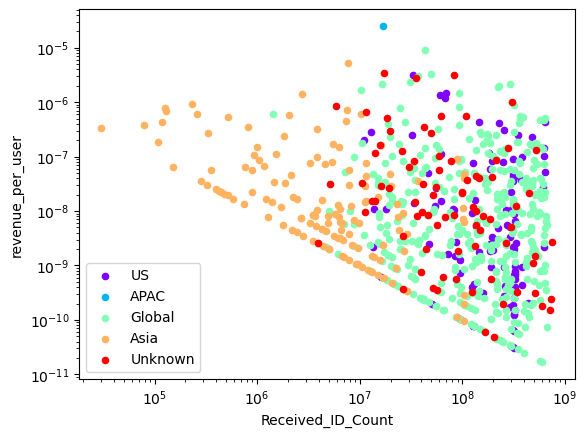

In [61]:
get_split_plots2(dat1_sample, x='Received_ID_Count', y='revenue_per_user', kind='scatter', by='geo', logx=True, logy=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Avg_Relevance', ylabel='ecpm'>

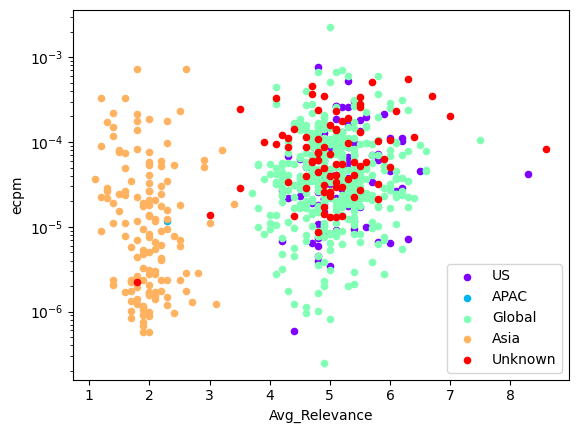

In [62]:
get_split_plots2(dat1_sample, x='Avg_Relevance', y='ecpm', kind='scatter', by='geo', logx=False, logy=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='ecpm', ylabel='Data_Cost'>

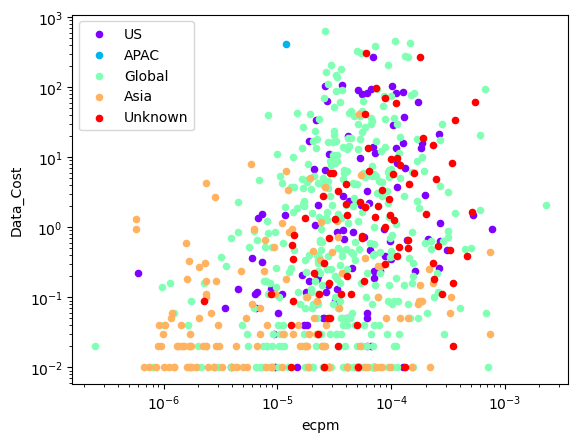

In [63]:
get_split_plots2(dat1_sample, y='Data_Cost', x='ecpm', kind='scatter', by='geo', logx=True, logy=True)

<Axes: xlabel='Avg_Relevance', ylabel='Match_Pct'>

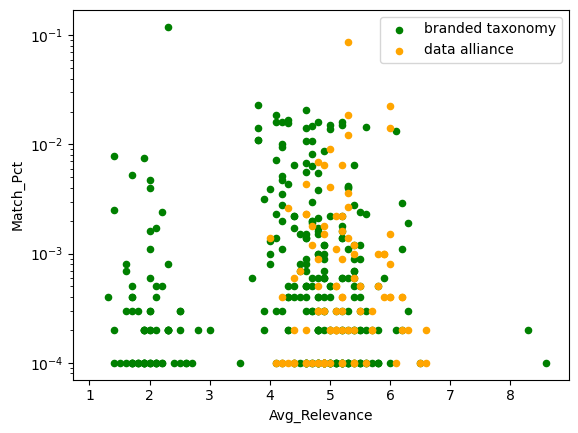

In [64]:
get_split_plots(dat1_sample, y='Match_Pct', x='Avg_Relevance', logy=True, logx=False)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Avg_Relevance', ylabel='Data_Cost'>

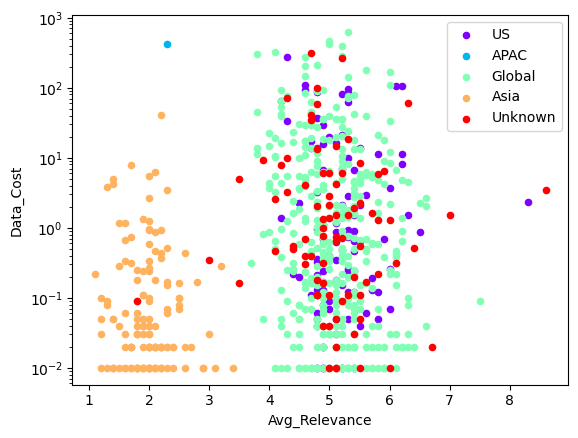

In [65]:
#get_split_plots(dat1_sample, y='Data_Cost', x='Avg_Relevance', logy=True, logx=False)
get_split_plots2(dat1_sample, y='Data_Cost', x='Avg_Relevance', by='geo', logy=True, logx=False)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Avg_Relevance_Percentile', ylabel='Data_Cost'>

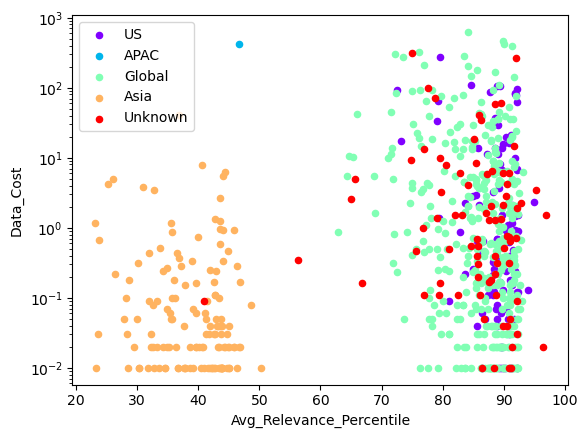

In [66]:
#get_split_plots(dat1_sample, y='Data_Cost', x='Avg_Relevance_Percentile', logy=True, logx=False)
get_split_plots2(dat1_sample, y='Data_Cost', by='geo', x='Avg_Relevance_Percentile', logy=True, logx=False)

In [67]:
dat1[['Received_ID_Count', 'Active_ID_Count', 'Effective_Impression_Count', 'Avg_Relevance', 'Match_Pct', 'Avg_Relevance_Percentile']].astype(float).describe(
    percentiles = [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
).round(2)

,Received_ID_Count,Active_ID_Count,Effective_Impression_Count,Avg_Relevance,Match_Pct,Avg_Relevance_Percentile
count,3.412500e+04,3.412500e+04,34125.00,34125.00,34125.00,34125.00
mean,1.446507e+08,6.900885e+07,308156.52,4.32,0.00,74.44
std,1.723304e+08,7.807430e+07,2146718.59,1.47,0.01,21.51
min,7.200000e+03,3.600000e+03,0.00,1.00,0.00,15.80
5%,8.894000e+05,4.543000e+05,7.00,1.70,0.00,34.10
10%,2.411440e+06,1.276000e+06,35.00,1.90,0.00,38.90
25%,1.227900e+07,6.775100e+06,260.00,3.00,0.00,48.20
50%,6.279980e+07,3.310190e+07,3340.00,4.90,0.00,86.10
75%,2.439385e+08,1.185025e+08,46657.00,5.30,0.00,90.00
90%,4.048077e+08,1.902791e+08,370353.80,5.80,0.00,91.70


array([[<Axes: title={'center': 'Received_ID_Count'}>,
        <Axes: title={'center': 'Effective_Impression_Count'}>]],
      dtype=object)

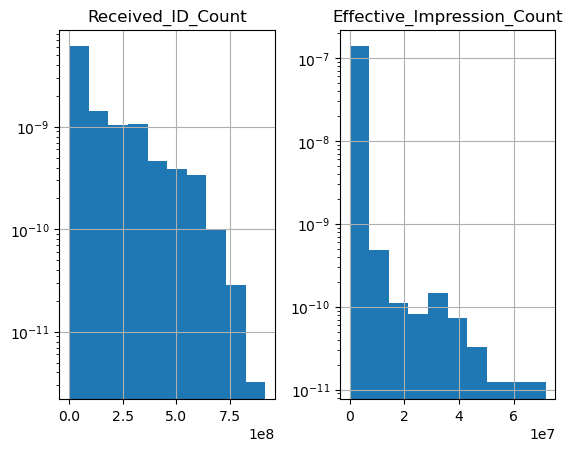

In [68]:
dat1[['Received_ID_Count', 'Effective_Impression_Count']].astype(float).hist(density=True, log=True)

In [69]:
#dat1.hist(column=['Received_ID_Count', 'Effective_Impression_Count'], density=True, by='Third_Party_Data_Provider_Id', log=True)

In [70]:
dat1[['Received_ID_Count', 'Effective_Impression_Count']].astype(float).describe(
    percentiles = [0.1, 0.5, 0.9]
).round(2)

,Received_ID_Count,Effective_Impression_Count
count,3.412500e+04,34125.00
mean,1.446507e+08,308156.52
std,1.723304e+08,2146718.59
min,7.200000e+03,0.00
10%,2.411440e+06,35.00
50%,6.279980e+07,3340.00
90%,4.048077e+08,370353.80
max,9.140841e+08,71678810.00


In [71]:
dat1['Match_Pct'].max(), dat1['Effective_Impression_Count'].quantile(0.95).round(2), dat1['Received_ID_Count'].quantile(0.05).round(2)

(0.4245, 989147.8, 889400.0)

array([[<Axes: title={'center': 'Received_ID_Count'}>,
        <Axes: title={'center': 'Active_ID_Count'}>,
        <Axes: title={'center': 'Effective_Impression_Count'}>]],
      dtype=object)

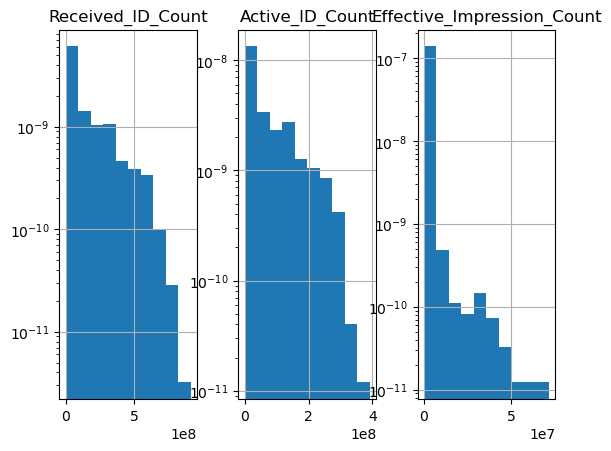

In [72]:
dat1[['Received_ID_Count', 'Active_ID_Count', 'Effective_Impression_Count']].astype(float).hist(density=True, layout=(1,3), log=True)

array([[<Axes: title={'center': 'Match_Pct'}>,
        <Axes: title={'center': 'Avg_Relevance'}>,
        <Axes: title={'center': 'Avg_Relevance_Percentile'}>]],
      dtype=object)

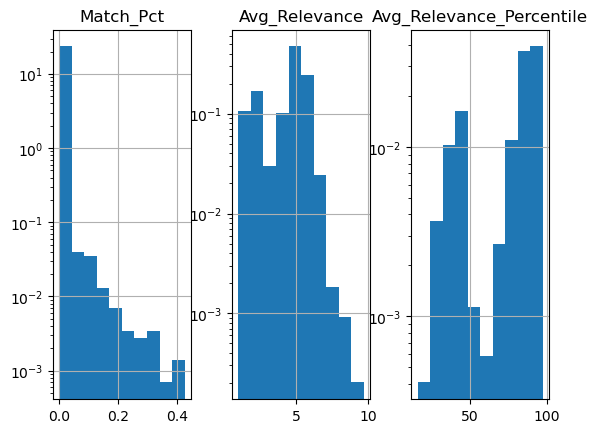

In [73]:
dat1[['Match_Pct', 'Avg_Relevance', 'Avg_Relevance_Percentile']].astype(float).hist(density=True, layout=(1,3), log=True)

In [74]:
dat2 = dat1

array([[<Axes: title={'center': 'Avg_Relevance'}>,
        <Axes: title={'center': 'Data_Cost'}>]], dtype=object)

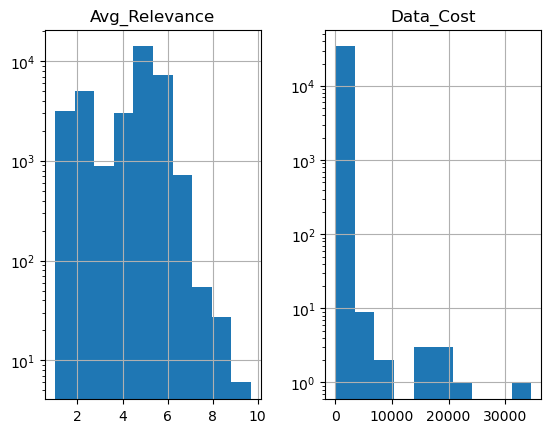

In [75]:
dat2[['Avg_Relevance', 'Data_Cost']].hist(log=True)

In [76]:
dat2[['Avg_Relevance', 'Data_Cost']].describe()

,Avg_Relevance,Data_Cost
count,34125.000000,34125.000000
mean,4.316067,19.154214
std,1.472554,350.958919
min,1.000000,0.000000
25%,3.000000,0.000000
50%,4.900000,0.060000
75%,5.300000,1.370000
max,9.700000,34596.840000


In [77]:
dat2[['Data_Cost']].describe(percentiles=[0.5, 0.7, 0.8, 0.9, 0.95, 0.99])

,Data_Cost
count,34125.000000
mean,19.154214
std,350.958919
min,0.000000
50%,0.060000
70%,0.670000
80%,2.890000
90%,14.726000
95%,46.504000
99%,278.553600


Text(0.5, 1.0, 'log2 (1 + data_cost)')

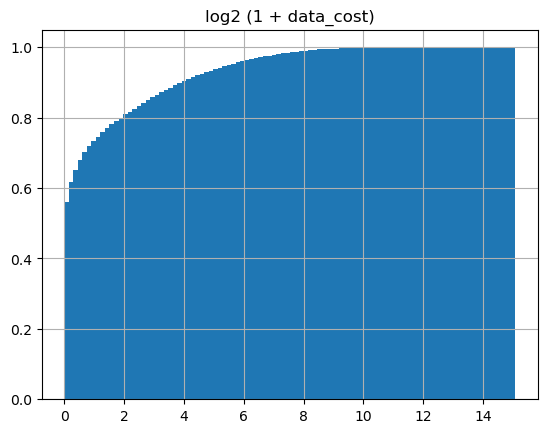

In [78]:
np.log2(dat2[['Data_Cost']] + 1).hist(bins=100, cumulative=True, density=True)
plt.title('log2 (1 + data_cost)')

# Model

In [79]:
#y = dat2['Data_Cost'].astype(float) / (dat2['Effective_Impression_Count'].astype(float) + 1)
yr = dat2['Avg_Relevance']
yd = dat2['Data_Cost'].astype(float) 

In [80]:
seg_col = 'segment_last'
#seg_col = 'segment_2'
#seg_col = 'Full_Path'

In [81]:
x_c_cols = [seg_col, 'week_start', 'Advertiser_Category', 'Third_Party_Data_Provider_Id', 'geo', 'segment_2']
x_n_cols = ['Received_ID_Count'] #[ 'Active_ID_Count_Percentile', 'Avg_Relevance_Percentile', 'Paid_Pct_Percentile']
# 'Avg_Value_Percentile' has NAs

In [82]:
Xn = pd.DataFrame(dat2[x_n_cols], dtype=float)
Xn['log_Received_ID_Count'] = Xn['Received_ID_Count'].apply(lambda x: np.log(x))

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
Xn = pd.DataFrame(sc.fit_transform(Xn), columns=Xn.columns, index=Xn.index)

In [83]:
Xc = pd.get_dummies(dat2[x_c_cols])

In [84]:
dat2.head()

,Week_Start_Date,Full_Path,Advertiser_Category,Third_Party_Data_Provider_Id,Third_Party_Data_Sub_Provider_Id,Received_ID_Count,Active_ID_Count,Active_ID_Count_Percentile,Effective_Impression_Count,Data_Cost,...,Match_Pct,Match_Pct_Percentile,Paid_Pct,Paid_Pct_Percentile,geo,Clean_Path,segment_last,segment_1,segment_2,week_start
0,2025-10-20 00:00:00 UTC,Data Alliance > Retail > Interest > Global > M...,All,dav2shreths,None,469500300,223662800,97.0,210,0.00,...,0.0000,59.6,10.7,64.5,Global,"dataalliance>retail>interest>global>movies,mus...",sportstv,dataalliance,retail,2025-10-20
2,2025-10-20 00:00:00 UTC,Data Alliance > Business & Finance > Interest ...,All,dav2shreths,None,327039700,164794400,96.0,583411,31.85,...,0.0017,97.1,99.9,90.8,Global,dataalliance>business&finance>interest>global>...,businessnews,dataalliance,business&finance,2025-10-20
3,2025-10-20 00:00:00 UTC,Data Alliance > Food & Beverages > Interest > ...,All,dav2shreths,None,354196300,177782000,96.3,155,0.00,...,0.0000,59.6,100.0,91.8,Global,dataalliance>food&beverages>interest>global>me...,desserts,dataalliance,food&beverages,2025-10-20
5,2025-10-20 00:00:00 UTC,Data Alliance > Education > Interest > Global ...,All,dav2shreths,None,218865800,113109100,94.7,214112,3.61,...,0.0007,94.9,94.3,84.3,Global,dataalliance>education>interest>global>busines...,businesseducation,dataalliance,education,2025-10-20
6,2025-10-20 00:00:00 UTC,Data Alliance > Business & Finance > Interest ...,All,dav2shreths,None,11714400,6594000,81.9,162,0.00,...,0.0000,59.6,100.0,91.8,Global,dataalliance>business&finance>interest>global>...,financialreform,dataalliance,business&finance,2025-10-20


In [85]:
#matches

In [86]:
Xc.head()

,segment_last_$1-$100million,segment_last_$100-$500million,segment_last_$10million-$20million,segment_last_$1million-$10million,segment_last_$20million-$50million,segment_last_$500-$1billion,segment_last_$50million-$100million,segment_last_1-star,segment_last_1500,segment_last_18+,...,segment_2_supremecourt,segment_2_technicalreference,segment_2_technology&computing,segment_2_thechangingconsumer,segment_2_toyshoppers,segment_2_travel,segment_2_travelers,segment_2_urlaudience,segment_2_us,segment_2_validateddemographic
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [87]:
Xn.head()

,Received_ID_Count,log_Received_ID_Count
0,1.885067,1.180627
2,1.058384,1.000299
3,1.215971,1.040081
5,0.430662,0.800006
6,-0.771415,-0.660039


In [88]:
Xc.head()

,segment_last_$1-$100million,segment_last_$100-$500million,segment_last_$10million-$20million,segment_last_$1million-$10million,segment_last_$20million-$50million,segment_last_$500-$1billion,segment_last_$50million-$100million,segment_last_1-star,segment_last_1500,segment_last_18+,...,segment_2_supremecourt,segment_2_technicalreference,segment_2_technology&computing,segment_2_thechangingconsumer,segment_2_toyshoppers,segment_2_travel,segment_2_travelers,segment_2_urlaudience,segment_2_us,segment_2_validateddemographic
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [89]:
X = Xn.join(Xc)
X.head()

,Received_ID_Count,log_Received_ID_Count,segment_last_$1-$100million,segment_last_$100-$500million,segment_last_$10million-$20million,segment_last_$1million-$10million,segment_last_$20million-$50million,segment_last_$500-$1billion,segment_last_$50million-$100million,segment_last_1-star,...,segment_2_supremecourt,segment_2_technicalreference,segment_2_technology&computing,segment_2_thechangingconsumer,segment_2_toyshoppers,segment_2_travel,segment_2_travelers,segment_2_urlaudience,segment_2_us,segment_2_validateddemographic
0,1.885067,1.180627,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1.058384,1.000299,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1.215971,1.040081,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,0.430662,0.800006,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,-0.771415,-0.660039,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [90]:
X.shape

(34125, 3062)

### Relevance

In [91]:
from sklearn.linear_model import Ridge

mod_r = Ridge(alpha=0.000001, fit_intercept=True)
mod_r.fit(X, yr)
mod_r.score(X, yr)

0.9615507544301486

In [92]:
coef_r = pd.DataFrame(mod_r.coef_, index=X.columns, columns=['beta'])
coef_r['abs_beta'] = coef_r['beta'].abs()
coef_r_sorted = coef_r.sort_values('abs_beta', ascending=False)

In [93]:
coef_r_sorted[coef_r_sorted.beta > 0].filter(regex=seg_col, axis='index').head(15)

,beta,abs_beta
segment_last_medicalliterature&resources,2.045802,2.045802
segment_last_mainlandchina,1.928156,1.928156
segment_last_singapore,1.743421,1.743421
segment_last_asia,1.661237,1.661237
segment_last_arthritis,1.642116,1.642116
segment_last_constipation,1.641560,1.641560
segment_last_outdoorentertainers,1.639721,1.639721
segment_last_malaysia,1.625930,1.625930
segment_last_hairloss,1.618606,1.618606
segment_last_acidreflux,1.589393,1.589393


In [94]:
coef_r_sorted[coef_r_sorted.beta < 0].filter(regex=seg_col, axis='index').head(15)

,beta,abs_beta
segment_last_valdemings,-2.955956,2.955956
segment_last_mariannewilliamson,-2.631091,2.631091
segment_last_larryelder,-2.599045,2.599045
segment_last_rifter,-2.321074,2.321074
segment_last_restaurant,-2.320835,2.320835
segment_last_308sw,-2.259597,2.259597
segment_last_ronaldharoldjohnson,-2.194810,2.194810
segment_last_traveller,-2.107014,2.107014
segment_last_timryan,-2.061524,2.061524
segment_last_staceyabrams,-2.058105,2.058105


<Axes: title={'center': 'seasonality of avg relevance'}, xlabel='week'>

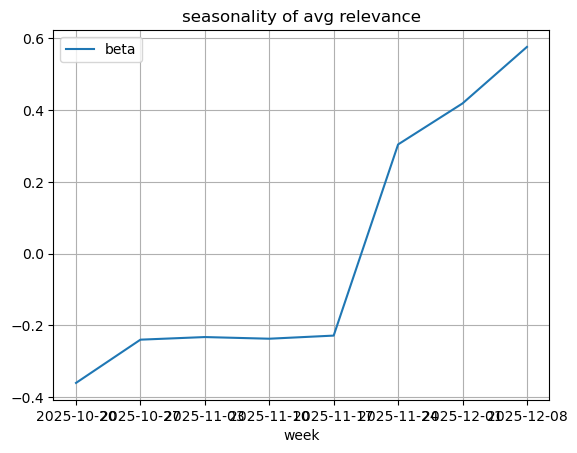

In [95]:
r_seas = coef_r.filter(regex='week_', axis='index')[['beta']].reset_index()
r_seas['week'] = r_seas['index'].apply(lambda x: x.split('_')[-1])
r_seas.plot(x='week', y='beta', grid=True, title='seasonality of avg relevance')

In [96]:
coef_r.filter(regex='Received', axis='index')

,beta,abs_beta
Received_ID_Count,-0.342403,0.342403
log_Received_ID_Count,0.313253,0.313253


In [97]:
coef_r.filter(regex='geo_', axis='index')

,beta,abs_beta
geo_APAC,-1.774987,1.774987
geo_Asia,-1.689368,1.689368
geo_Global,1.090834,1.090834
geo_US,1.397916,1.397916
geo_Unknown,0.975535,0.975535


In [98]:
coef_r.filter(regex='Third_Party_Data_Provider_Id', axis='index')

,beta,abs_beta
Third_Party_Data_Provider_Id_dav2shreths,0.000934,0.000934
Third_Party_Data_Provider_Id_sharethis,-0.000934,0.000934


### Revenue

In [99]:
from sklearn.linear_model import Ridge

mod_d_simple = Ridge(alpha=0.000001)
X2 = X[['Received_ID_Count']].join(yr)
mod_d_simple.fit(X2, yd)
mod_d_simple.score(X2, yd), mod_d_simple.coef_

(0.004130149229996771, array([23.12168208, -1.65862291]))

In [100]:
X2.head()

,Received_ID_Count,Avg_Relevance
0,1.885067,4.2
2,1.058384,4.4
3,1.215971,4.4
5,0.430662,4.5
6,-0.771415,4.5


In [101]:
from sklearn.linear_model import Ridge

mod_d = Ridge(alpha=0.000001)
mod_d.fit(X, yd)
mod_d.score(X, yd)

0.3472880094005061

In [102]:
coef_d = pd.DataFrame(mod_d.coef_, index=X.columns, columns=['beta'])
coef_d['abs_beta'] = coef_d['beta'].abs()
coef_d_sorted = coef_d.sort_values('abs_beta', ascending=False)

In [103]:
coef_d_sorted[coef_d_sorted.beta > 0].filter(regex=seg_col, axis='index').head(15)

,beta,abs_beta
segment_last_18-44,7116.883038,7116.883038
segment_last_foodservices,4610.235302,4610.235302
segment_last_65-69,1764.929173,1764.929173
segment_last_pickuptrucks&suvs,1248.137505,1248.137505
segment_last_smallandminorityownedbusinesses,1159.559930,1159.559930
segment_last_sleepdisorders,1049.145944,1049.145944
segment_last_adventuretravel,844.505607,844.505607
segment_last_25-54,804.614010,804.614010
segment_last_female,713.652925,713.652925
segment_last_greenliving&environmentalissues,559.632489,559.632489


In [104]:
coef_d_sorted[coef_d_sorted.beta < 0].filter(regex=seg_col, axis='index').head(15)

,beta,abs_beta
segment_last_fathersday,-144.527527,144.527527
segment_last_valdemings,-142.457936,142.457936
segment_last_blackfridayshoppers,-124.657851,124.657851
segment_last_mothersday,-122.265768,122.265768
segment_last_cybermondayshoppers,-109.159858,109.159858
segment_last_mariannewilliamson,-105.922856,105.922856
segment_last_larryelder,-100.597517,100.597517
segment_last_goldenglobes,-99.029825,99.029825
segment_last_micro(1-20employees),-92.933605,92.933605
segment_last_medium(101-500employees),-88.603621,88.603621


<Axes: title={'center': 'seasonality of revenue'}, xlabel='week'>

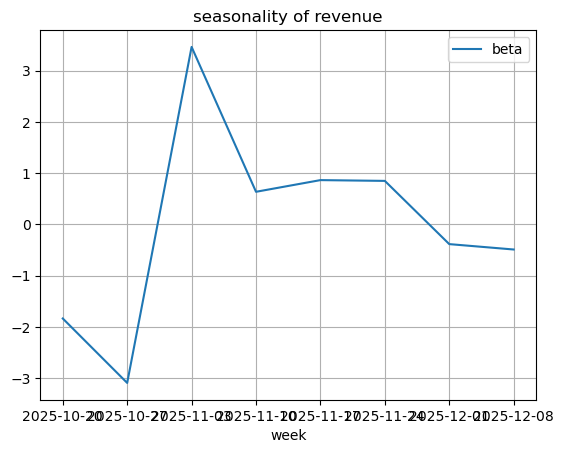

In [105]:
#coef_d.filter(regex='week', axis='index')

d_seas = coef_d.filter(regex='week_', axis='index')[['beta']].reset_index()
d_seas['week'] = d_seas['index'].apply(lambda x: x.split('_')[-1])
d_seas.plot(x='week', y='beta', grid=True, title='seasonality of revenue')

In [106]:
coef_d.filter(regex='Received', axis='index')

,beta,abs_beta
Received_ID_Count,13.408206,13.408206
log_Received_ID_Count,-36.871780,36.871780


In [107]:
coef_d.filter(regex='geo_', axis='index')

,beta,abs_beta
geo_APAC,39.775452,39.775452
geo_Asia,-66.311681,66.311681
geo_Global,44.463512,44.463512
geo_US,2.745200,2.745200
geo_Unknown,-20.671044,20.671044


In [108]:
coef_d.filter(regex='Third_Party_Data_Provider_Id', axis='index')

,beta,abs_beta
Third_Party_Data_Provider_Id_dav2shreths,-21.075242,21.075242
Third_Party_Data_Provider_Id_sharethis,21.075245,21.075245


In [109]:
segs_check = [x.replace(seg_col+'_', '') for x in coef_r_sorted.index[:1]]
dat2[dat2[seg_col].isin(segs_check)].head(5).T

""
Week_Start_Date
Full_Path
Advertiser_Category
Third_Party_Data_Provider_Id
Third_Party_Data_Sub_Provider_Id
Received_ID_Count
Active_ID_Count
Active_ID_Count_Percentile
Effective_Impression_Count
Data_Cost


In [110]:
segs_d_check = [x.replace(seg_col+'_', '') for x in coef_d_sorted.index[:1]]
dat2[dat2[seg_col].isin(segs_d_check)].head(5).T

,2609,3498,3772,8372,9276
Week_Start_Date,2025-10-20 00:00:00 UTC,2025-10-20 00:00:00 UTC,2025-10-20 00:00:00 UTC,2025-10-27 00:00:00 UTC,2025-10-27 00:00:00 UTC
Full_Path,Asia > Validated Demographic > Age > 18-44,Global > Validated Demographic > Age > 18-44,US > Validated Demographic > Age > 18-44,Asia > Validated Demographic > Age > 18-44,Global > Validated Demographic > Age > 18-44
Advertiser_Category,All,All,All,All,All
Third_Party_Data_Provider_Id,sharethis,sharethis,sharethis,sharethis,sharethis
Third_Party_Data_Sub_Provider_Id,None,None,None,None,None
Received_ID_Count,79811500,614675900,614437100,79811500,614675900
Active_ID_Count,39496100,283874100,266169400,39496100,283874100
Active_ID_Count_Percentile,90.5,97.7,97.5,90.4,97.7
Effective_Impression_Count,68,46077957,459686,67,43178548
Data_Cost,0.0,18798.67,18.23,0.0,16289.16


In [111]:
coef_rd = coef_r.join(coef_d, lsuffix='_rel', rsuffix='_rev')

In [112]:
coef_seg = coef_rd.filter(regex=seg_col, axis='index')

In [113]:
coef_seg.head()

,beta_rel,abs_beta_rel,beta_rev,abs_beta_rev
segment_last_$1-$100million,0.071632,0.071632,2.278910,2.278910
segment_last_$100-$500million,0.066430,0.066430,2.687010,2.687010
segment_last_$10million-$20million,0.167832,0.167832,0.503570,0.503570
segment_last_$1million-$10million,0.130656,0.130656,-0.285842,0.285842
segment_last_$20million-$50million,0.164016,0.164016,2.202702,2.202702


In [114]:
coef_seg.corr()

,beta_rel,abs_beta_rel,beta_rev,abs_beta_rev
beta_rel,1.000000,-0.192125,0.095551,0.048664
abs_beta_rel,-0.192125,1.000000,0.015639,0.071483
beta_rev,0.095551,0.015639,1.000000,0.974826
abs_beta_rev,0.048664,0.071483,0.974826,1.000000


In [115]:
coef_seg.describe()

,beta_rel,abs_beta_rel,beta_rev,abs_beta_rev
count,2.954000e+03,2954.000000,2954.000000,2954.000000
mean,-3.396576e-09,0.282233,-0.000002,37.015620
std,3.982795e-01,0.280970,173.325859,169.325820
min,-2.955956e+00,0.000125,-144.527527,0.000139
25%,-2.093224e-01,0.106559,-29.693391,8.770026
50%,1.574478e-02,0.220882,-14.135986,20.567812
75%,2.384233e-01,0.358769,0.380594,37.802135
max,2.045802e+00,2.955956,7116.883038,7116.883038


<Axes: title={'center': 'correlation between revenue and relevance'}, xlabel='beta_rel', ylabel='beta_rev'>

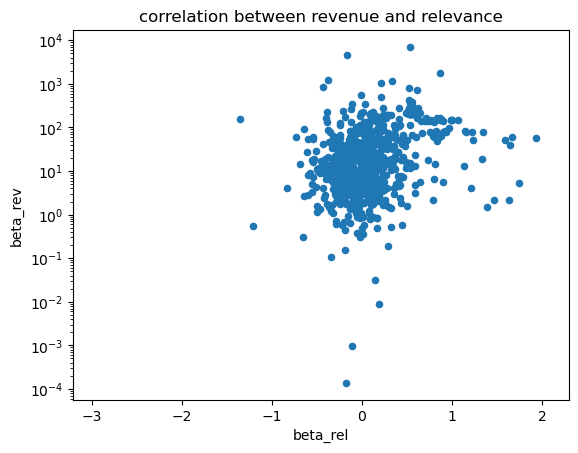

In [116]:
coef_seg.plot(kind='scatter', x='beta_rel', y='beta_rev', logy=True, title='correlation between revenue and relevance')

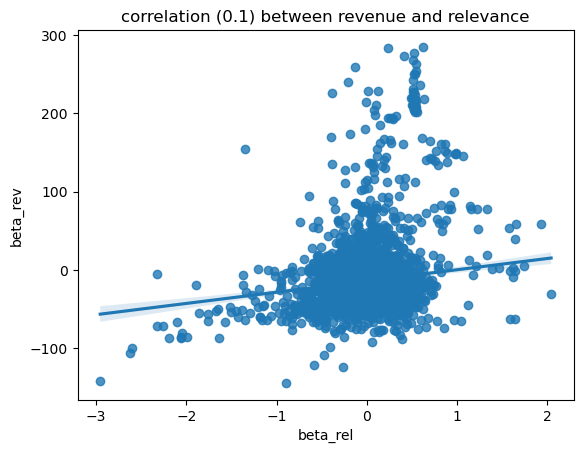

In [117]:
x = coef_seg[coef_seg.beta_rev < 300]['beta_rel'].values
y = coef_seg[coef_seg.beta_rev < 300]['beta_rev'].values

ax = sns.regplot(x=x, y=y,  robust=True)
ax.set(xlabel='beta_rel', ylabel='beta_rev')
# Optional: Add a title
ax.set_title('correlation (0.1) between revenue and relevance')
plt.show()

array([[<Axes: title={'center': 'beta_rel'}>,
        <Axes: title={'center': 'beta_rev'}>]], dtype=object)

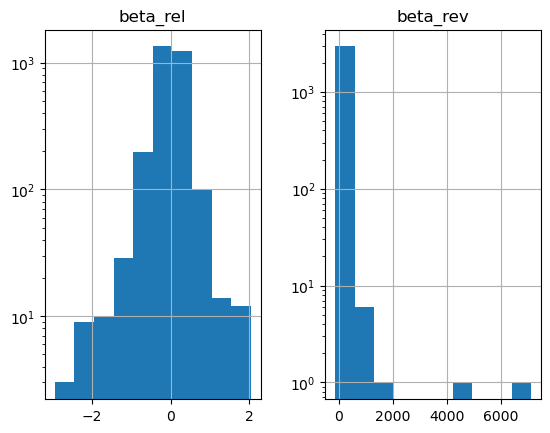

In [118]:
coef_seg[['beta_rel', 'beta_rev']].hist(log=True)

In [119]:
#coef_seg.plot(kind='scatter', x='beta_rel', y='beta_rev', logy=True, title='correlation between revenue and relevance')
#x = coef_seg['beta_rel'].values
#y = coef_seg['beta_rev'].values
#z = np.polyfit(x, y, deg=3)
#p = np.poly1d(z)
#line_y = p(x)
##line_y = slope * x + intercept
##plt.plot(x, line_y, color='red', linestyle='--', label='Trend Line')
#plt.scatter(x, line_y, color='red', label='Trend Line')

<Axes: xlabel='Avg_Relevance', ylabel='Data_Cost'>

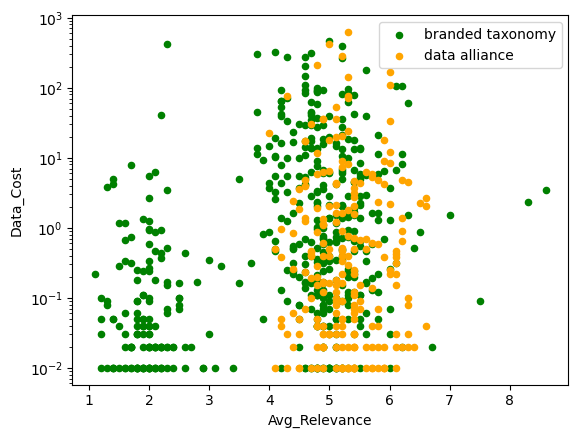

In [120]:
# for comparison
get_split_plots(dat1_sample, y='Data_Cost', x='Avg_Relevance', logy=True, logx=False)

### select test segments

In [121]:
seg_col

'segment_last'

In [122]:
coef_r2 = coef_r.filter(regex=seg_col, axis='index').reset_index()
coef_r2['index'] = coef_r2['index'].apply(lambda x: x.replace(seg_col + '_', ''))
coef_r2 = coef_r2.set_index('index')

coef_r2 = coef_r2.join(dat2.set_index(seg_col)[['Received_ID_Count', 'Avg_Relevance', 'Data_Cost']])
coef_r3 = coef_r2.groupby(level=0)[['beta', 'Received_ID_Count', 'Avg_Relevance', 'Data_Cost']].mean()

In [123]:
dat_last = dat2.groupby('Full_Path').last()
coef_r3 = coef_r3.join(
    dat_last.reset_index().set_index(seg_col)[
    ['Full_Path', 'week_start', 'Received_ID_Count', 'Avg_Relevance', 'Data_Cost', 'geo', 'Third_Party_Data_Provider_Id', 'segment_2']
    ], rsuffix='_latest'
)

<Axes: xlabel='Received_ID_Count', ylabel='beta'>

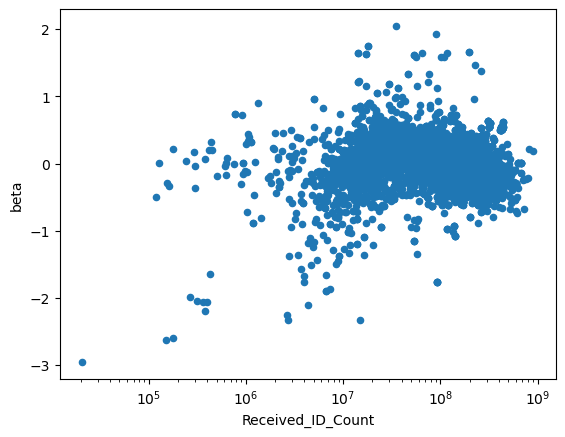

In [124]:
coef_r3.plot(kind='scatter', y='beta', x='Received_ID_Count', logx=True)

<Axes: xlabel='beta', ylabel='Avg_Relevance'>

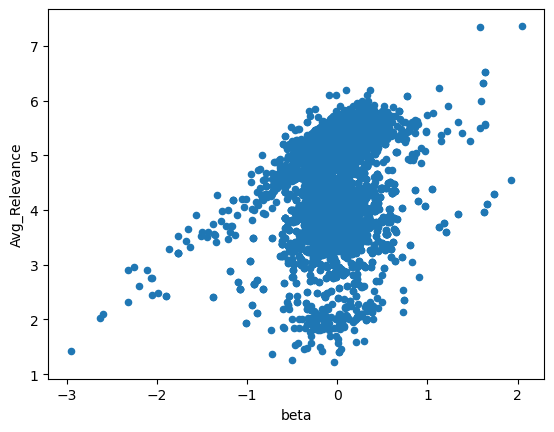

In [125]:
coef_r3.plot(kind='scatter', x='beta', y='Avg_Relevance')

<Axes: xlabel='beta', ylabel='Data_Cost'>

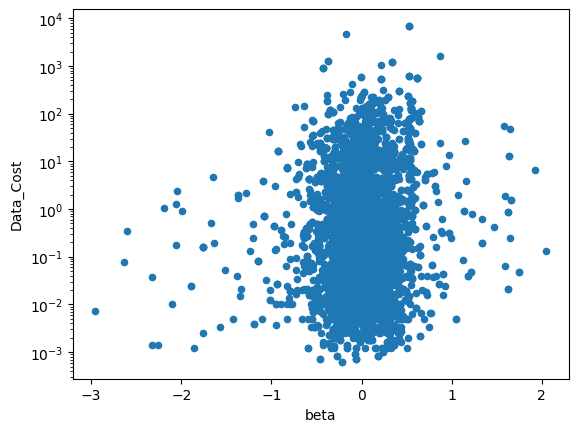

In [126]:
coef_r3.plot(kind='scatter', x='beta', y='Data_Cost', logy=True)

array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'Received_ID_Count'}>]], dtype=object)

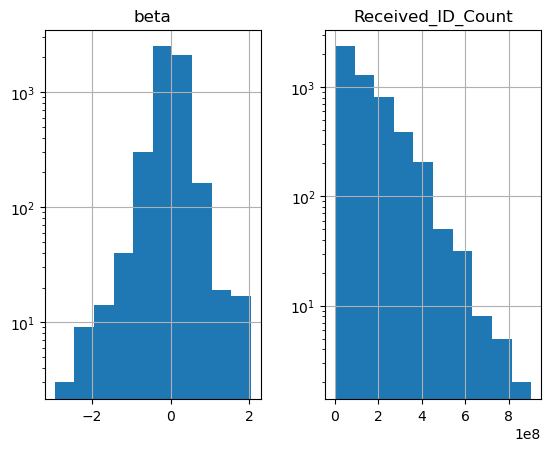

In [127]:
coef_r3[['beta', 'Received_ID_Count']].hist(log=True)

In [128]:
refresh = False

In [129]:
if refresh:
    selected_small = coef_r3[(coef_r3['Received_ID_Count'] < 1000000)]
    selected_small['criterion'] = 'small_size'
    selected_neg = coef_r3[(coef_r3['beta'] < -1)]
    selected_neg['criterion'] = 'low_relevance'
    selected_pos = coef_r3[(coef_r3['beta'] > 1)]
    selected_pos['criterion'] = 'high_relevance'
    selected = pd.concat([selected_small, selected_neg, selected_pos, selected_ord])
    selected = selected[~selected.index.duplicated(keep='first')]

    selected.to_csv('../../Projects/TTD/selected_for_experiment_with_ordinary.csv')
else:
    print ("loading selected")
    selected = pd.read_csv('../../Projects/TTD/selected_for_experiment_with_ordinary.csv', index_col=0)

loading selected


In [130]:
selected.groupby('criterion').size()

criterion
high_relevance    26
low_relevance     39
oridinary         99
small_size        34
dtype: int64

In [131]:
selected[selected.geo == 'Global'].groupby('criterion').size()

criterion
high_relevance     2
low_relevance     24
oridinary         59
dtype: int64

In [132]:
selected.groupby('geo').size()

geo
Asia       58
Global     85
US         22
Unknown    33
dtype: int64

In [133]:
selected.shape

(198, 13)

In [134]:
len(set(selected['Full_Path']))

198

In [135]:
selected.head()

,beta,Received_ID_Count,Avg_Relevance,Data_Cost,Full_Path,week_start,Received_ID_Count_latest,Avg_Relevance_latest,Data_Cost_latest,geo,Third_Party_Data_Provider_Id,segment_2,criterion
index,,,,,,,,,,,,,
atms&branchlocations,-0.166924,624866.666667,1.416667,0.003333,Asia > Finance > Banking > ATMs & Branch Locat...,2025-12-01,681000,1.6,0.00,Asia,sharethis,finance,small_size
ayannapressley,-1.638623,423820.000000,3.320000,0.190000,Political > Politician > Ayanna Pressley,2025-12-08,372600,4.3,0.33,Unknown,sharethis,politician,small_size
bank-owned&foreclosedproperties,-0.011817,748675.000000,1.700000,0.005000,Asia > Real Estate > Bank-Owned & Foreclosed P...,2025-12-08,707100,2.3,0.00,Asia,sharethis,realestate,small_size
billing&invoicing,-0.038139,302500.000000,1.225000,0.045000,Asia > Finance > Accounting & Auditing > Billi...,2025-11-10,307600,1.3,0.00,Asia,sharethis,finance,small_size
biographies&quotations,0.740978,767012.500000,2.350000,0.000000,Asia > Reference > General Reference > Biograp...,2025-10-27,730800,1.7,0.00,Asia,sharethis,reference,small_size


In [136]:
selected.groupby(['criterion'])[['beta', 'Received_ID_Count', 'Data_Cost']].describe(percentiles=[0.5]).round(2).T

criterion                high_relevance  low_relevance     oridinary  \
beta              count    2.600000e+01   3.900000e+01  9.900000e+01   
                  mean     1.440000e+00  -1.430000e+00 -1.000000e-02   
                  std      2.700000e-01   3.700000e-01  3.200000e-01   
                  min      1.050000e+00  -2.320000e+00 -9.400000e-01   
                  50%      1.430000e+00  -1.350000e+00  0.000000e+00   
                  max      2.050000e+00  -1.010000e+00  6.600000e-01   
Received_ID_Count count    2.600000e+01   3.900000e+01  9.900000e+01   
                  mean     7.222526e+07   1.920464e+07  1.350522e+08   
                  std      6.648738e+07   3.301573e+07  1.248644e+08   
                  min      1.417663e+07   2.669743e+06  2.206125e+06   
                  50%      5.528613e+07   7.273138e+06  9.486440e+07   
                  max      2.622358e+08   1.412916e+08  6.298389e+08   
Data_Cost         count    2.600000e+01   3.900000e+01  9.900000e+01   
                  mean     6.340000e+00   1.480000e+00  3.250000e+00   
                  std      1.475000e+01   6.580000e+00  7.730000e+00   
                  min      0.000000e+00   0.000000e+00  0.000000e+00   
                  50%      5.100000e-01   2.000000e-02  1.400000e-01   
                  max      5.625000e+01   4.104000e+01  4.870000e+01   

criterion                small_size  
beta              count       34.00  
                  mean        -0.58  
                  std          1.06  
                  min         -2.96  
                  50%         -0.13  
                  max          0.74  
Received_ID_Count count       34.00  
                  mean    449858.06  
                  std     275330.96  
                  min      20828.57  
                  50%     393643.75  
                  max     990320.00  
Data_Cost         count       34.00  
                  mean         0.23  
                  std          0.51  
                  min          0.00  
                  50%          0.02  
                  max          2.40

array([[<Axes: title={'center': 'high_relevance'}>,
        <Axes: title={'center': 'low_relevance'}>],
       [<Axes: title={'center': 'oridinary'}>,
        <Axes: title={'center': 'small_size'}>]], dtype=object)

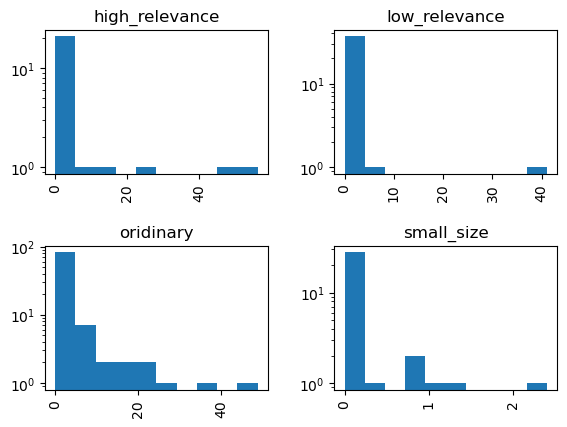

In [137]:
selected.hist('Data_Cost', by='criterion', log=True)

In [138]:
selected.groupby(['geo'])[['beta', 'Received_ID_Count', 'Data_Cost']].describe(percentiles=[0.5]).round(2).T

geo                              Asia        Global            US  \
beta              count  5.800000e+01  8.500000e+01  2.200000e+01   
                  mean   1.600000e-01 -3.700000e-01  5.200000e-01   
                  std    7.800000e-01  7.600000e-01  9.100000e-01   
                  min   -1.900000e+00 -2.320000e+00 -8.000000e-01   
                  50%    8.000000e-02 -1.300000e-01  1.100000e-01   
                  max    1.930000e+00  1.120000e+00  2.050000e+00   
Received_ID_Count count  5.800000e+01  8.500000e+01  2.200000e+01   
                  mean   5.018365e+07  9.471941e+07  1.493608e+08   
                  std    8.632063e+07  1.125618e+08  1.076025e+08   
                  min    1.188500e+05  2.669743e+06  1.361440e+07   
                  50%    1.015644e+07  4.999699e+07  1.139974e+08   
                  max    4.206614e+08  5.532944e+08  4.341500e+08   
Data_Cost         count  5.800000e+01  8.500000e+01  2.200000e+01   
                  mean   1.390000e+00  2.910000e+00  6.500000e+00   
                  std    2.980000e+00  8.770000e+00  1.556000e+01   
                  min    0.000000e+00  0.000000e+00  0.000000e+00   
                  50%    4.000000e-02  4.000000e-02  1.100000e-01   
                  max    1.272000e+01  4.870000e+01  5.625000e+01   

geo                           Unknown  
beta              count  3.300000e+01  
                  mean  -8.700000e-01  
                  std    1.310000e+00  
                  min   -2.960000e+00  
                  50%   -1.240000e+00  
                  max    1.590000e+00  
Received_ID_Count count  3.300000e+01  
                  mean   5.347148e+07  
                  std    1.131355e+08  
                  min    2.082857e+04  
                  50%    1.661614e+07  
                  max    6.298389e+08  
Data_Cost         count  3.300000e+01  
                  mean   2.480000e+00  
                  std    5.890000e+00  
                  min    0.000000e+00  
                  50%    5.200000e-01  
                  max    2.719000e+01

In [139]:
selected.groupby(['Third_Party_Data_Provider_Id'])[['beta', 'Received_ID_Count', 'Data_Cost']].describe(percentiles=[0.5]).round(2)

beta                                \
                              count  mean   std   min   50%   max   
Third_Party_Data_Provider_Id                                        
dav2shreths                    65.0 -0.47  0.85 -2.32 -0.29  1.93   
sharethis                     133.0 -0.07  1.02 -2.96 -0.01  2.05   

                             Received_ID_Count                             \
                                         count         mean           std   
Third_Party_Data_Provider_Id                                                
dav2shreths                               65.0  67698280.58  1.033259e+08   
sharethis                                133.0  87307586.90  1.114835e+08   

                                                                    Data_Cost  \
                                     min          50%           max     count   
Third_Party_Data_Provider_Id                                                    
dav2shreths                   2669742.86  24259333.33  5.532944e+08      65.0   
sharethis                       20828.57  40501850.00  6.298389e+08     133.0   

                                                            
                              mean   std  min   50%    max  
Third_Party_Data_Provider_Id                                
dav2shreths                   1.24  5.21  0.0  0.01  41.04  
sharethis                     3.55  9.38  0.0  0.17  56.25

array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'Received_ID_Count'}>],
       [<Axes: title={'center': 'Data_Cost'}>, <Axes: >]], dtype=object)

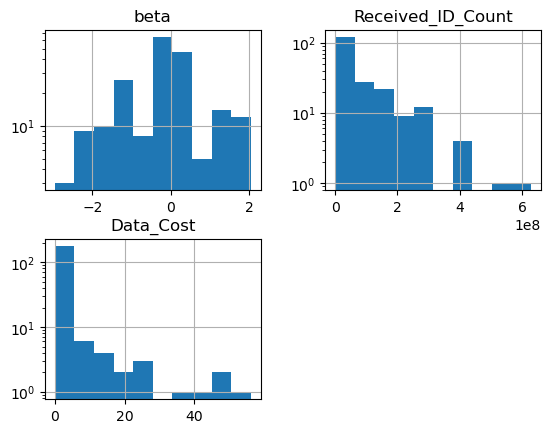

In [140]:
selected[['beta', 'Received_ID_Count', 'Data_Cost']].hist(log=True)

In [198]:
import matplotlib.pyplot as plt

def dfScatter(df, xcol='beta', ycol='Received_ID_Count', catcol='criterion', logx=False, logy=False):
    #fig, ax = plt.subplots()
    categories = np.unique(df[catcol])
    colors = np.linspace(0, 1, len(categories))
    colordict = dict(zip(categories, colors))  

    colors = df[catcol].apply(lambda x: colordict[x])
    #x.scatter(df[xcol], df[ycol], c=colors, logx=logx, logy=logy)
    return df.plot(kind='scatter', x=xcol, y=ycol, logy=logy, logx=logx, c=colors)
    #return df.plot(kind='scatter', x='beta', y='Received_ID_Count', logy=logy, logx=logx, c=catcol, colormap='viridis')
    #return fig

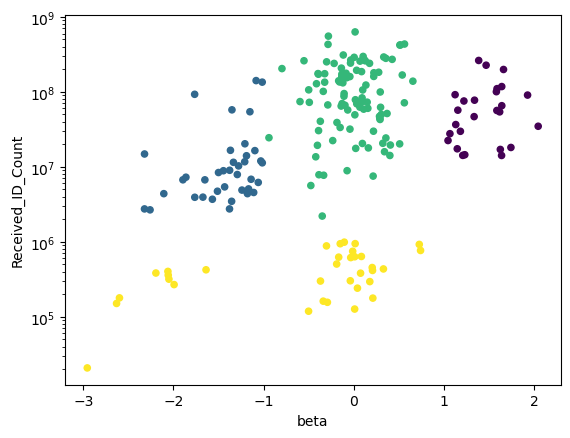

In [142]:
fig = dfScatter(selected, logy=True)

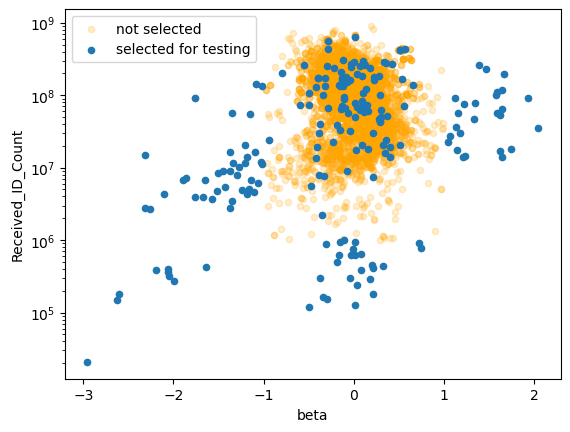

In [143]:
ax=coef_r3[['beta', 'Received_ID_Count']].plot(kind='scatter', x='beta', y='Received_ID_Count', logy=True, color='orange', alpha=0.2, label='not selected')
ax=selected[['beta', 'Received_ID_Count']].plot(ax=ax, kind='scatter', x='beta', y='Received_ID_Count', logy=True, label='selected for testing')

In [144]:
#selected[['beta', 'Received_ID_Count']].plot(kind='scatter', x='beta', y='Received_ID_Count', logy=True)

In [145]:
#ax=coef_r3[['beta', 'Received_ID_Count']].plot(kind='scatter', x='beta', y='Received_ID_Count', logy=True, color='orange', alpha=0.2, label='not selected')
#ax=selected[['beta', 'Received_ID_Count']].plot(ax=ax, kind='scatter', x='beta', y='Received_ID_Count', logy=True, label='selected for testing')

In [146]:
selected.describe()

,beta,Received_ID_Count,Avg_Relevance,Data_Cost,Received_ID_Count_latest,Avg_Relevance_latest,Data_Cost_latest
count,198.000000,1.980000e+02,198.000000,198.000000,1.980000e+02,198.000000,198.000000
mean,-0.199648,8.087019e+07,3.893851,2.790679,8.449727e+07,4.419697,2.536667
std,0.985670,1.090019e+08,1.291908,8.304560,1.334264e+08,1.656633,8.040072
min,-2.955956,2.082857e+04,1.225000,0.000000,1.410000e+04,1.300000,0.000000
25%,-0.746336,5.462091e+06,3.229375,0.007530,3.438250e+06,2.800000,0.000000
50%,-0.076678,3.267539e+07,3.927273,0.071875,1.437650e+07,4.850000,0.010000
75%,0.287878,1.218266e+08,4.929018,1.050658,1.017370e+08,5.875000,0.345000
max,2.045802,6.298389e+08,7.362500,56.253750,6.084802e+08,8.400000,53.610000


In [147]:
selected.head()

,beta,Received_ID_Count,Avg_Relevance,Data_Cost,Full_Path,week_start,Received_ID_Count_latest,Avg_Relevance_latest,Data_Cost_latest,geo,Third_Party_Data_Provider_Id,segment_2,criterion
index,,,,,,,,,,,,,
atms&branchlocations,-0.166924,624866.666667,1.416667,0.003333,Asia > Finance > Banking > ATMs & Branch Locat...,2025-12-01,681000,1.6,0.00,Asia,sharethis,finance,small_size
ayannapressley,-1.638623,423820.000000,3.320000,0.190000,Political > Politician > Ayanna Pressley,2025-12-08,372600,4.3,0.33,Unknown,sharethis,politician,small_size
bank-owned&foreclosedproperties,-0.011817,748675.000000,1.700000,0.005000,Asia > Real Estate > Bank-Owned & Foreclosed P...,2025-12-08,707100,2.3,0.00,Asia,sharethis,realestate,small_size
billing&invoicing,-0.038139,302500.000000,1.225000,0.045000,Asia > Finance > Accounting & Auditing > Billi...,2025-11-10,307600,1.3,0.00,Asia,sharethis,finance,small_size
biographies&quotations,0.740978,767012.500000,2.350000,0.000000,Asia > Reference > General Reference > Biograp...,2025-10-27,730800,1.7,0.00,Asia,sharethis,reference,small_size


### huanjin's questions

In [190]:
can1 = dat1.set_index(seg_col)[['Full_Path', 'geo', 'Data_Cost', 'Received_ID_Count', 'Avg_Relevance', 'Avg_Relevance_Percentile', 'Selected_Pct', 'Selected_Pct_Percentile']].join(selected[['criterion']], how='left').reset_index()
can1['criterion'] = can1['criterion'].fillna('not_selected')
can1['revenue_per_user'] = can1['Data_Cost'] / can1['Received_ID_Count']

In [191]:
can1.head()

,segment_last,Full_Path,geo,Data_Cost,Received_ID_Count,Avg_Relevance,Avg_Relevance_Percentile,Selected_Pct,Selected_Pct_Percentile,criterion,revenue_per_user
0,sportstv,Data Alliance > Retail > Interest > Global > M...,Global,0.00,469500300,4.2,80.9,0.0004,56.8,not_selected,0.000000e+00
1,businessnews,Data Alliance > Business & Finance > Interest ...,Global,31.85,327039700,4.4,83.9,0.0034,84.7,oridinary,9.738879e-08
2,desserts,Data Alliance > Food & Beverages > Interest > ...,Global,0.00,354196300,4.4,83.6,0.0004,56.8,not_selected,0.000000e+00
3,businesseducation,Data Alliance > Education > Interest > Global ...,Global,3.61,218865800,4.5,86.7,0.0017,77.1,not_selected,1.649413e-08
4,financialreform,Data Alliance > Business & Finance > Interest ...,Global,0.00,11714400,4.5,86.8,0.0017,77.1,not_selected,0.000000e+00


In [192]:
can1[['Avg_Relevance', 'Selected_Pct']].describe(percentiles=[0.1, 0.25, 0.5, 0.75])

,Avg_Relevance,Selected_Pct
count,34125.000000,34056.000000
mean,4.316067,0.013937
std,1.472554,0.137340
min,1.000000,0.000400
10%,1.900000,0.000400
25%,3.000000,0.000800
50%,4.900000,0.002000
75%,5.300000,0.005700
max,9.700000,3.896400


In [211]:
can1g = can1.groupby([seg_col, 'Full_Path', 'geo', 'criterion'])[['Data_Cost', 'Received_ID_Count', 
                                                                  'Avg_Relevance', 'Avg_Relevance_Percentile',
                                                                  'Selected_Pct', 'Selected_Pct_Percentile']].mean().round(4)
can1g.shape

(5144, 6)

In [217]:
can1g_global = can1g.xs('Global', level='geo')

<Axes: xlabel='Selected_Pct', ylabel='Avg_Relevance'>

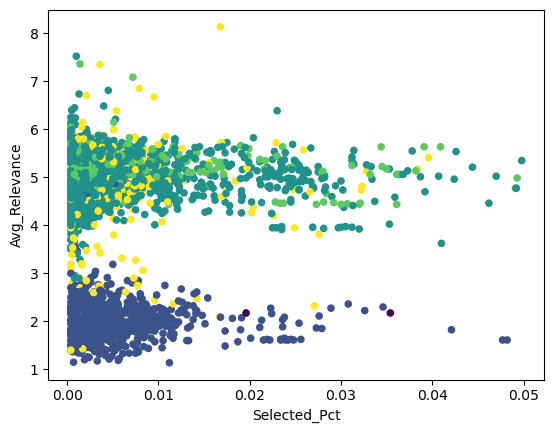

In [212]:
dfScatter(can1g[can1g.Selected_Pct < 0.05].reset_index(), xcol='Selected_Pct', ycol='Avg_Relevance', catcol='geo')

In [222]:
#can1g[can1g.Selected_Pct < 0.05].reset_index().plot(kind='scatter', x='Selected_Pct', y='Avg_Relevance')

<Axes: xlabel='Selected_Pct', ylabel='Avg_Relevance'>

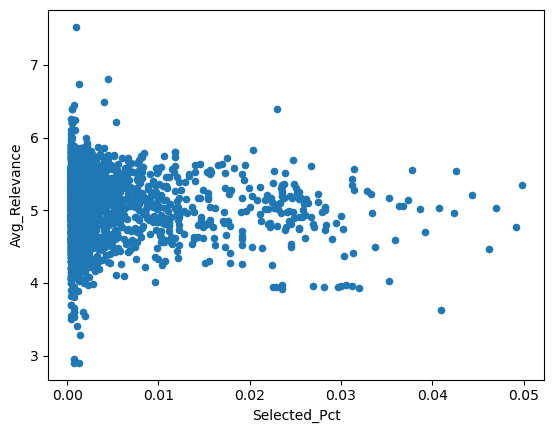

In [218]:
can1g_global[can1g_global.Selected_Pct < 0.05].reset_index().plot(kind='scatter', x='Selected_Pct', y='Avg_Relevance')

<Axes: xlabel='Selected_Pct', ylabel='Data_Cost'>

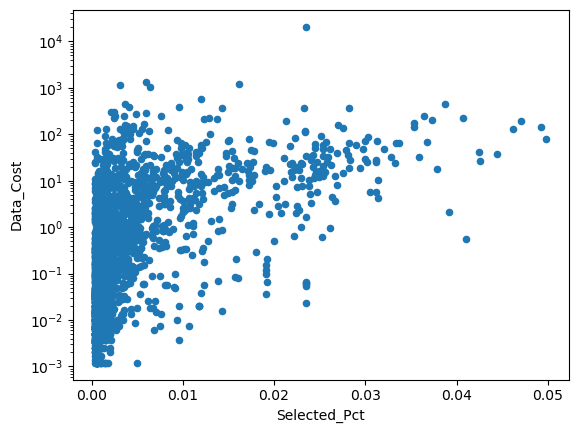

In [224]:
can1g_global[can1g_global.Selected_Pct < 0.05].reset_index().plot(kind='scatter', x='Selected_Pct', y='Data_Cost', logy=True)

In [225]:
can1g[(can1g.Selected_Pct < 0.001) & (can1g.Data_Cost > 10)]

,,,,Data_Cost,Received_ID_Count,Avg_Relevance,Avg_Relevance_Percentile,Selected_Pct,Selected_Pct_Percentile
segment_last,Full_Path,geo,criterion,,,,,,
allinclusiveresorts,Data Alliance > Travel > Interest > Global > Travel Type > All Inclusive Resorts,Global,not_selected,14.9588,2.037225e+08,5.2375,89.1875,0.0007,64.5125
athletics,Data Alliance > Sports > Interest > Global > Athletics,Global,not_selected,32.1625,2.512664e+08,5.1250,87.9125,0.0006,62.0750
cooking&recipes,Global > food & drink > cooking & recipes,Global,not_selected,28.9338,6.307222e+08,4.3000,74.9000,0.0009,68.2250
ecosport,Data Alliance > Automotive > Interest > Global > Autos > Brand > Ford > Model > Ecosport,Global,not_selected,13.8967,1.276330e+08,5.0667,91.0333,0.0007,63.8667
finearts,Data Alliance > Arts & Entertainment > Interest > Global > Fine Arts,Global,not_selected,64.1225,5.159298e+08,4.7000,77.0250,0.0006,63.1000
internationalrelations,Data Alliance > Education > Interest > Global > Field of Study > Social Sciences > International Relations,Global,not_selected,121.7088,1.735510e+08,5.2625,89.3000,0.0006,63.1375
kitchencleaning,Intent > CPG > Household > Kitchen Products > Kitchen Cleaning,Unknown,not_selected,12.9643,1.387906e+07,4.9286,86.1857,0.0008,66.5714
laundry,Data Alliance > CPG > Interest > Global > Household Care > Laundry,Global,not_selected,24.5250,1.908034e+08,4.9500,90.4500,0.0004,56.5000
new,Intent > Auto Buyers > New,Unknown,oridinary,18.7838,1.099898e+08,5.6625,91.1250,0.0007,63.1000


In [194]:
can1g.to_csv('../../Projects/TTD/candidate_segs.csv')

In [149]:
#can11 = can1[can1.geo == 'Global']
can11 = can1[can1.geo != 'Asia']

can12 = can11[can11.criterion != 'oridinary']
can13 = can11[can11.criterion != 'not_selected']

In [150]:
#get_split_plots2(can12, y='Data_Cost', x='Avg_Relevance', by='criterion', logy=True, logx=False, alpha=0.5)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Avg_Relevance', ylabel='Data_Cost'>

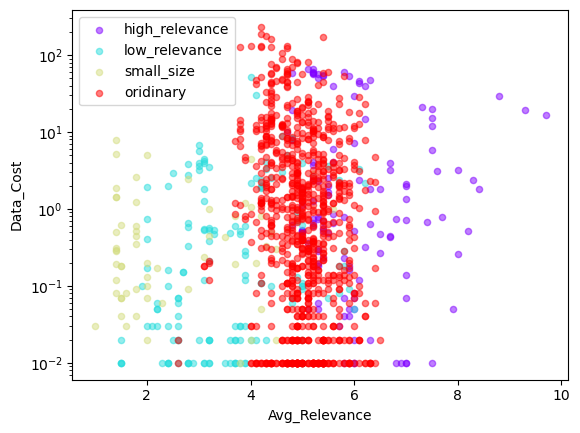

In [151]:
get_split_plots2(can13, y='Data_Cost', x='Avg_Relevance', by='criterion', logy=True, logx=False, alpha=0.5)

In [152]:
#get_split_plots2(can12, y='Data_Cost', x='Received_ID_Count', by='criterion', logy=True, logx=True, alpha=0.1)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Received_ID_Count', ylabel='Data_Cost'>

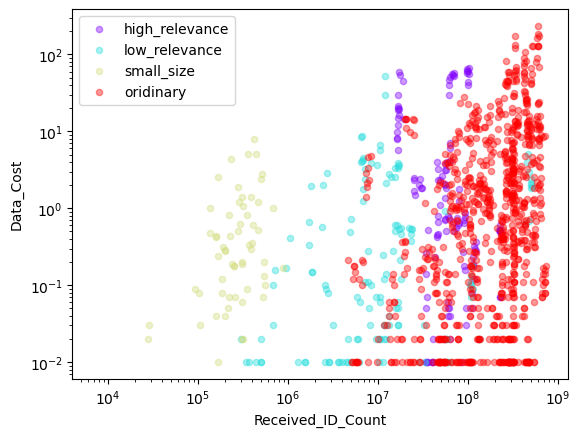

In [153]:
get_split_plots2(can13, y='Data_Cost', x='Received_ID_Count', by='criterion', logy=True, logx=True, alpha=0.4)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Received_ID_Count', ylabel='Data_Cost'>

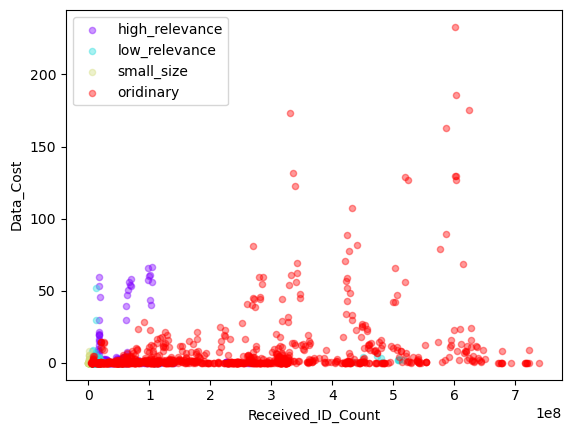

In [154]:
get_split_plots2(can13, y='Data_Cost', x='Received_ID_Count', by='criterion', logy=False, logx=False, alpha=0.4)

In [155]:
#get_split_plots2(can12, y='revenue_per_user', x='Avg_Relevance', by='criterion', logy=True, logx=False, alpha=0.9)

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(
/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks li

<Axes: xlabel='Avg_Relevance', ylabel='revenue_per_user'>

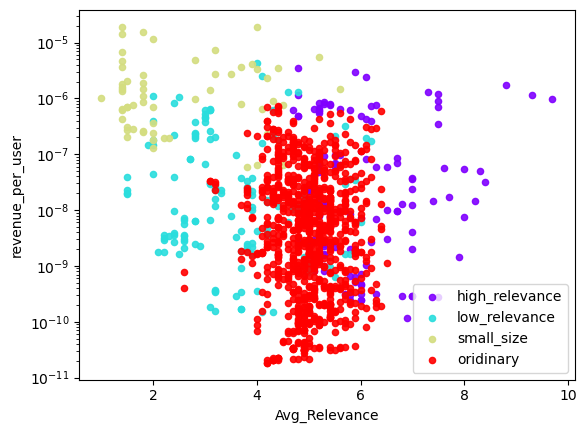

In [156]:
get_split_plots2(can13, y='revenue_per_user', x='Avg_Relevance', by='criterion', logy=True, logx=False, alpha=0.9)

In [157]:
#can2 = pd.DataFrame(dat1.groupby('Full_Path')[['Data_Cost']].mean()).join(selected.set_index('Full_Path')[['criterion']], how='left').reset_index()
can2 = pd.DataFrame(dat1.groupby(seg_col)[['Data_Cost']].mean()).join(selected[['criterion']], how='left').reset_index()
can2['criterion'] = can2['criterion'].fillna('not_selected')

In [158]:
can2.shape

(2954, 3)

In [159]:
can2.head()

,segment_last,Data_Cost,criterion
0,$1-$100million,0.52125,not_selected
1,$100-$500million,1.12750,not_selected
2,$10million-$20million,0.31500,not_selected
3,$1million-$10million,0.24375,not_selected
4,$20million-$50million,2.21000,not_selected


array([[<Axes: title={'center': 'high_relevance'}>,
        <Axes: title={'center': 'low_relevance'}>],
       [<Axes: title={'center': 'not_selected'}>,
        <Axes: title={'center': 'oridinary'}>],
       [<Axes: title={'center': 'small_size'}>, <Axes: >]], dtype=object)

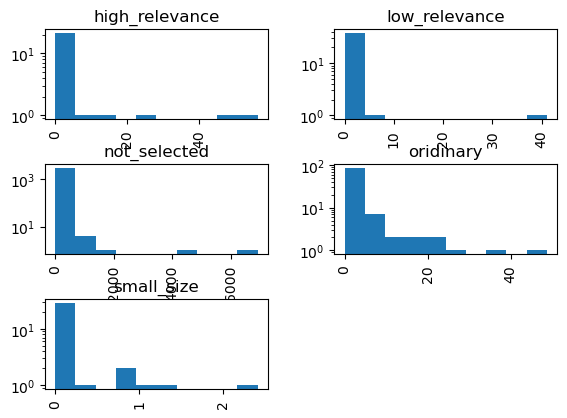

In [160]:
can2.hist(column='Data_Cost', by='criterion', log=True)

In [161]:
can2.groupby('criterion')[['Data_Cost']].describe()

Data_Cost                                                  \
                   count       mean         std  min       25%       50%   
criterion                                                                  
high_relevance      26.0   6.344136   14.746940  0.0  0.053068  0.512589   
low_relevance       39.0   1.483321    6.582170  0.0  0.001429  0.020000   
not_selected      2756.0  14.359985  169.669027  0.0  0.008333  0.105000   
oridinary           99.0   3.250899    7.730291  0.0  0.015120  0.135000   
small_size          34.0   0.232892    0.507473  0.0  0.005536  0.019464   

                                       
                     75%          max  
criterion                              
high_relevance  1.969375    56.253750  
low_relevance   0.204625    41.035000  
not_selected    1.558750  6916.252083  
oridinary       2.155833    48.700667  
small_size      0.152589     2.405000

In [162]:
can2.groupby('criterion')[['Data_Cost']].describe(percentiles=[.2, .25, .3,  0.75, .85, .9, .95, 0.99]).T

criterion        high_relevance  low_relevance  not_selected  oridinary  \
Data_Cost count       26.000000      39.000000   2756.000000  99.000000   
          mean         6.344136       1.483321     14.359985   3.250899   
          std         14.746940       6.582170    169.669027   7.730291   
          min          0.000000       0.000000      0.000000   0.000000   
          20%          0.049000       0.000750      0.004000   0.007460   
          25%          0.053068       0.001429      0.008333   0.015120   
          30%          0.076250       0.002833      0.013750   0.023543   
          50%          0.512589       0.020000      0.105000   0.135000   
          75%          1.969375       0.204625      1.558750   2.155833   
          85%          8.033437       0.997687      6.302375   5.003431   
          90%         19.955625       1.974750     13.988958   9.431250   
          95%         43.136250       3.883375     43.478229  19.311708   
          99%         54.303125      27.206800    185.343344  37.573450   
          max         56.253750      41.035000   6916.252083  48.700667   

criterion        small_size  
Data_Cost count   34.000000  
          mean     0.232892  
          std      0.507473  
          min      0.000000  
          20%      0.003583  
          25%      0.005536  
          30%      0.007464  
          50%      0.019464  
          75%      0.152589  
          85%      0.369500  
          90%      0.892000  
          95%      1.140125  
          99%      2.026738  
          max      2.405000

<Axes: title={'center': 'Data_Cost'}, xlabel='criterion'>

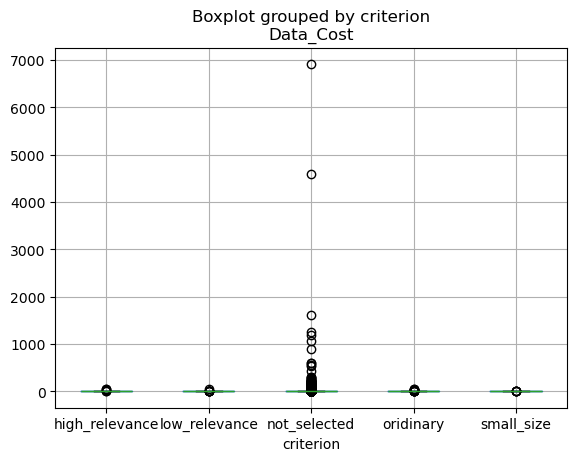

In [163]:
can2.boxplot(column='Data_Cost', by='criterion')

In [164]:
can2.\
groupby('criterion')[['Data_Cost']].max()

,Data_Cost
criterion,
high_relevance,56.253750
low_relevance,41.035000
not_selected,6916.252083
oridinary,48.700667
small_size,2.405000


<Axes: title={'center': 'Data_Cost'}, xlabel='criterion'>

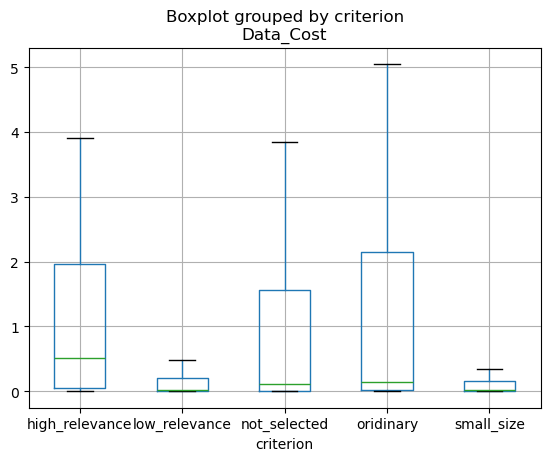

In [165]:
can2.boxplot(column='Data_Cost', by='criterion', showfliers=False)

In [166]:
from sklearn.ensemble import RandomForestRegressor as RFR

In [167]:
X_rf = X[X.columns[X.columns != 'log_Received_ID_Count']]

In [168]:
X_rf[['Received_ID_Count']].head()

,Received_ID_Count
0,1.885067
2,1.058384
3,1.215971
5,0.430662
6,-0.771415


In [169]:
sc.inverse_transform(X[['Received_ID_Count',	'log_Received_ID_Count']].head())

array([[4.69500300e+08, 1.99671795e+01],
       [3.27039700e+08, 1.96055921e+01],
       [3.54196300e+08, 1.96853618e+01],
       [2.18865800e+08, 1.92039693e+01],
       [1.17144000e+07, 1.62763294e+01]])

In [170]:
sc.inverse_transform([[1, 1]])

array([[3.16978548e+08, 1.96049917e+01]])

In [171]:
mod_r_rf = RFR(max_depth=5)
mod_r_rf.fit(X_rf, yr)
mod_r_rf.score(X_rf, yr)

0.905264069205441

In [172]:
coef_r_rf = pd.DataFrame(mod_r_rf.feature_importances_, index=X_rf.columns, columns=['feature_importance'])
coef_r_rf_sorted = coef_r_rf.sort_values('feature_importance', ascending=False)
coef_r_rf_sorted.head(20)

,feature_importance
geo_Asia,0.892000
Received_ID_Count,0.053734
week_start_2025-12-08,0.026060
week_start_2025-12-01,0.016427
week_start_2025-11-24,0.004455
geo_APAC,0.003602
segment_2_travel,0.002716
segment_2_generalreference,0.000344
Third_Party_Data_Provider_Id_dav2shreths,0.000107
geo_Global,0.000103


In [173]:
mod_d_rf = RFR(max_depth=5)
mod_d_rf.fit(X_rf, yd)
mod_d_rf.score(X_rf, yd)

0.9419553167282668

In [174]:
coef_d_rf = pd.DataFrame(mod_d_rf.feature_importances_, index=X_rf.columns, columns=['feature_importance'])
coef_d_rf_sorted = coef_d_rf.sort_values('feature_importance', ascending=False)
ç.head(20)

NameError: name 'ç' is not defined

In [ ]:
samples = pd.DataFrame(np.arange(1, 1000) * 1000000,  columns=['Received_ID_Count'])
samples['log_Received_ID_Count'] = samples['Received_ID_Count'].apply(lambda x: np.log(x))
samples_sc = pd.DataFrame(sc.transform(samples), columns=samples.columns, index=samples.index)

In [ ]:
samples_sc2 = pd.DataFrame(samples_sc[['Received_ID_Count']], copy=True)
samples_sc2['fake_index'] = X_rf.index[0]

In [ ]:
X_rf.head()

In [ ]:
X_rf['Received_ID_Count'].head()

In [ ]:
#samples.join(samples_sc, rsuffix='_sc').tail()

In [ ]:
X_rf2 = X_rf[X_rf.columns[X_rf.columns != 'Received_ID_Count']]
X_rf_forecast = samples_sc2.set_index('fake_index')[['Received_ID_Count']].join(X_rf2.head(1))
X_rf_forecast.shape

geos = ['geo_Asia', 'geo_US', 'geo_Global', 'geo_APAC']

yr_forecast = {}
yd_forecast = {}

for geo in geos:
    X_rf_forecast[geos] = False
    X_rf_forecast[geo] = True
    yr_forecast[geo] = mod_r_rf.predict(X_rf_forecast)
    yd_forecast[geo] = mod_d_rf.predict(X_rf_forecast)

for geo in geos:
    X_rf_forecast['relevance_forecast_' + geo] = yr_forecast[geo]
    X_rf_forecast['revenue_forecast_' + geo] = yd_forecast[geo]
X_rf_forecast['Received_ID_Count_unscaled'] = samples['Received_ID_Count'].values

rel_cols = ['relevance_forecast_' + geo for geo in geos]
rev_cols = ['revenue_forecast_' + geo for geo in geos]

X_rf_forecast.plot(x='Received_ID_Count_unscaled', y=rel_cols, grid=True, logx=True, ylabel='Relevance')
X_rf_forecast.plot(x='Received_ID_Count_unscaled', y=rev_cols, grid=True, logx=True, ylabel='Revenue')

In [ ]:
def plot_seg_forecasts(fc,
        x = 'Received_ID_Count_unscaled',
        y1 = 'relevance_forecast',
        y2 = 'revenue_forecast',
        x11 = None, #'Received_ID_Count_orig',
        y11 = None, #'current_size',
        title = '',
        legend_loc = None
    ):
    # 1. Get the current axes and create the second axes object
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx() # Instantiate a second axis that shares the same x-axis
    
    # 2. Plot the data on each axes object
    #y1 = y[0] if isinstance(y, list) else y
    ax1.plot(fc[x], fc[y1], color='blue', marker='.', label=y1, alpha=0.5)
    if x11 is not None and y11 is not None:
        ax1.plot(fc[x11], fc[y11], color='red', label=y11, alpha=0.7)
    ax2.plot(fc[x], fc[y2], color='green', marker='.', label=y2 + ' (right)')
    
    # 3. Set the labels
    ax1.set_xlabel(x)
    ax1.set_ylabel(y1, color='blue')
    ax2.set_ylabel(y2, color='green')
    
    # Optional: Improve layout and display legend
    if legend_loc:
        fig.tight_layout() # Ensures labels don't get clipped
        #ax1.legend(loc='lower left')
        #ax2.legend(loc='lower right')
        ax1.legend(loc=legend_loc)
        ax2.legend(loc=legend_loc)

    ax1.set_title(title)
    plt.show()


def get_seg_forecasts(X_rf, samples_sc, samples, seg_name, get_current_size=False, sc=None):
    idx=0
    X_rf = X_rf[X_rf[seg_name] == 1]#.tail(1)
    samples_sc2 = pd.DataFrame(samples_sc[['Received_ID_Count']], copy=True)
    samples_sc2['fake_index'] = X_rf.index[idx]
    X_rf2 = X_rf[X_rf.columns[X_rf.columns != 'Received_ID_Count']]
    X_rf_forecast = samples_sc2.set_index('fake_index')[['Received_ID_Count']].join(
        X_rf2.head(idx + 1).tail(1)
    )
    yr_forecast = mod_r_rf.predict(X_rf_forecast)
    yd_forecast = mod_d_rf.predict(X_rf_forecast)
    X_rf_forecast['relevance_forecast'] = yr_forecast
    X_rf_forecast['revenue_forecast'] = yd_forecast
        
    X_rf_forecast['Received_ID_Count_unscaled'] = samples['Received_ID_Count'].values
    
    if get_current_size:
        X_rf_forecast['Received_ID_Count_orig'] = sc.inverse_transform(
            [[X_rf['Received_ID_Count'].values[idx], 1]]
        )[0][0]
        mx_rel = X_rf_forecast['relevance_forecast'].max()
        mn_rel = X_rf_forecast['relevance_forecast'].min()
        mx_sz = X_rf_forecast['Received_ID_Count'].max()
        mn_sz = X_rf_forecast['Received_ID_Count'].min()
        X_rf_forecast['current_size'] = mn_rel + (X_rf_forecast['Received_ID_Count'] - mn_sz) * (mx_rel - mn_rel) / (mx_sz - mn_sz)
    
    #temp2 = pd.DataFrame(X_rf_forecast[X_rf_forecast.columns[["geo" in c for c in X_rf_forecast.columns]]].sum())
    #temp2.columns = ['sum']
    #print(temp2[temp2["sum"] > 0].index)

    return X_rf_forecast
    

def get_forecasts(X_rf, samples_sc, samples, idx=0, seg_col='segment_last', seg_name=None):
    samples_sc2 = pd.DataFrame(samples_sc[['Received_ID_Count']], copy=True)
    samples_sc2['fake_index'] = X_rf.index[idx]
    
    X_rf2 = X_rf[X_rf.columns[X_rf.columns != 'Received_ID_Count']]
    X_rf_forecast = samples_sc2.set_index('fake_index')[['Received_ID_Count']].join(
        X_rf2.head(idx + 1).tail(1)
    )
    
    geos = ['geo_Asia', 'geo_US', 'geo_Global', 'geo_APAC']
    
    yr_forecast = {}
    yd_forecast = {}
    
    for geo in geos:
        X_rf_forecast[geos] = False
        X_rf_forecast[geo] = True
        yr_forecast[geo] = mod_r_rf.predict(X_rf_forecast)
        yd_forecast[geo] = mod_d_rf.predict(X_rf_forecast)
    
    for geo in geos:
        g = geo.split('_')[1]
        X_rf_forecast['relevance_' + g] = yr_forecast[geo]
        X_rf_forecast['revenue_' + g] = yd_forecast[geo]
        
    X_rf_forecast['Received_ID_Count_unscaled'] = samples['Received_ID_Count'].values

    print (idx)
    temp = pd.DataFrame(X_rf_forecast[X_rf_forecast.columns[[seg_col in c for c in X_rf_forecast.columns]]].sum())
    temp.columns = ['sum']
    print(temp[temp["sum"] > 0].index)
    #temp2 = pd.DataFrame(X_rf_forecast[X_rf_forecast.columns[["geo" in c for c in X_rf_forecast.columns]]].sum())
    #temp2.columns = ['sum']
    #print(temp2[temp2["sum"] > 0].index)
    print(X_rf_forecast.shape)

    return X_rf_forecast

In [ ]:
fc_seg = get_seg_forecasts(X_rf, samples_sc, samples, seg_name='segment_last_18-44', get_current_size=True, sc=sc)
plot_seg_forecasts(fc_seg, y1='relevance_forecast', y2='revenue_forecast',
                   y11 = 'current_size', x11='Received_ID_Count_orig',
                   title='segment_last_18-44', legend_loc='best')

In [ ]:
temp2 = pd.DataFrame(X_rf[X_rf.columns[["geo" in c for c in X_rf.columns]]].sum())

temp2.columns = ['sum']
temp2[temp2["sum"] > 0]

In [ ]:
X_rf2.shape

In [ ]:
#temp = pd.DataFrame(fc[fc.columns[[seg_col in c for c in fc.columns]]].sum())
#temp = pd.DataFrame(X_rf[X_rf.columns[[seg_col in c for c in X_rf.columns]]].sum())
#temp = pd.DataFrame(X_rf2[X_rf2.columns[[seg_col in c for c in X_rf2.columns]]].sum())
#temp = pd.DataFrame(X_rf2.head(5)[X_rf2.columns[[seg_col in c for c in X_rf2.columns]]].sum())
temp = pd.DataFrame(X_rf_forecast[X_rf_forecast.columns[[seg_col in c for c in X_rf_forecast.columns]]].sum())

temp.columns = ['sum']
temp[temp["sum"] > 0].index

In [ ]:
import re

relc = [re.sub('forecast_geo_', '', item) for item in rel_cols]
revc = [re.sub('forecast_geo_', '', item) for item in rev_cols]

In [ ]:
temp1 = dat1[dat1['segment_last'] == 'partyfoods']
temp2 = temp1[temp1.geo == 'Asia']

In [ ]:
temp2.plot(x='week_start', y=['Received_ID_Count', 'Data_Cost'], secondary_y='Data_Cost', marker='*')

In [ ]:
segs = ['segment_last_18-44', 'segment_last_foodservices', 'segment_last_pickuptrucks&suvs', 'segment_last_partyfoods']
for seg in segs:
    #fc_seg = get_seg_forecasts(X_rf, samples_sc, samples, seg_name=seg)
    seg_n = seg.split('_')[-1]
    ##fc_seg.plot(x='Received_ID_Count_unscaled', y='relevance_forecast', grid=True, logx=True, ylabel='Relevance', title=seg_n + ': Relevance v/s size')
    ##fc_seg.plot(x='Received_ID_Count_unscaled', y='revenue_forecast', grid=True, logx=True, ylabel='Revenue', title=seg_n + ': Revenue v/s size')
    #fc_seg.plot(x='Received_ID_Count_unscaled', y=['revenue_forecast', 'relevance_forecast'], secondary_y='revenue_forecast',
    #            grid=True, logx=True, ylabel='Revenue', title=seg_n)
    fc_seg = get_seg_forecasts(X_rf, samples_sc, samples, seg_name=seg, get_current_size=True, sc=sc)
    plot_seg_forecasts(fc_seg, y1='relevance_forecast', y2='revenue_forecast',
                   y11 = 'current_size', x11='Received_ID_Count_orig',
                   title=seg_n, legend_loc=None)

In [ ]:
segs = ['segment_last_18-44', 'segment_last_foodservices', 'segment_last_pickuptrucks&suvs', 'segment_last_partyfoods']
segs_all = coef_d_rf_sorted.filter(regex=seg_col, axis='index').index
yr = {}
yd = {}
xrd = samples['Received_ID_Count'].values
for seg in segs_all:
    seg_n = seg.split('_')[-1]
    fc_seg = get_seg_forecasts(X_rf, samples_sc, samples, seg_name=seg, get_current_size=False, sc=None)
    yr[seg_n] = fc_seg['relevance_forecast'].values
    yd[seg_n] = fc_seg['revenue_forecast'].values
    #plot_seg_forecasts(fc_seg, y1='relevance_forecast', y2='revenue_forecast',
    #               title=seg_n, legend_loc=None)
yr_df = pd.DataFrame(yr)
yd_df = pd.DataFrame(yd)

In [ ]:
ps = [0.25, 0.5, 0.75, 0.95, 0.99]
yr_df_desc = yr_df.T.describe(percentiles=ps).T
yd_df_desc = np.log(yd_df).T.describe(percentiles=ps).T
yr_df_desc['size'] = xrd
yd_df_desc['size'] = xrd

In [ ]:
yr_df

In [ ]:
yr_df_desc

In [ ]:
yd_df_desc

In [ ]:
yd_df_desc

In [ ]:
yr_df_desc.plot(x='size', y=['mean', '25%', '50%', '75%', '99%'], title='Partial dependence of relevance on size', 
                ylabel='relevance', xlabel='segment size')

In [ ]:
#yd_df_desc.plot(x='size', y=['mean', '25%', '50%', '75%', '99%'], title='Partial dependence of revenue on size', 
#                ylabel='weekly revenue', xlabel='segment size')

yd_df_desc.plot(x='size', y=['mean', '25%', '50%', '75%', '99%'], title='Partial dependence of log(revenue) on size', 
                ylabel='weekly log(revenue)', xlabel='segment size')

In [ ]:
for idx in range(2):
    fc = get_forecasts(X_rf, samples_sc, samples, idx=idx, seg_col=seg_col)
    #print(fc.shape)
    fc.plot(x='Received_ID_Count_unscaled', y=relc, grid=True, logx=True, ylabel='Relevance', title='Relevance v/s size')
    fc.plot(x='Received_ID_Count_unscaled', y=revc, grid=True, logx=True, ylabel='Revenue', title='Revenue v/s size')

In [ ]:
X_rf2 = X_rf[X_rf.columns[X_rf.columns != 'Received_ID_Count']]
X_rf_forecast = samples_sc2.set_index('fake_index')[['Received_ID_Count']].join(X_rf2.head(1))
X_rf_forecast.shape

In [ ]:
yr_forecast = mod_r_rf.predict(X_rf_forecast)
yd_forecast = mod_d_rf.predict(X_rf_forecast)
X_rf_forecast['relevance_forecast'] = yr_forecast
X_rf_forecast['revenue_forecast'] = yd_forecast
X_rf_forecast['Received_ID_Count_unscaled'] = samples['Received_ID_Count'].values

In [ ]:
X_rf_forecast.plot(x='Received_ID_Count_unscaled', y='relevance_forecast', grid=True, logx=True)

In [ ]:
X_rf_forecast.plot(x='Received_ID_Count_unscaled', y='revenue_forecast', grid=True, logx=True)

## check current allocation

In [ ]:
seg_size = dat1.pivot_table(index='Full_Path', columns='week_start', values='Received_ID_Count')

In [ ]:
seg_size['Full_Path'] = 'Full_Path_' + seg_size.index

In [ ]:
seg_size_beta = seg_size.set_index('Full_Path').join(coef_r).join(coef_d, rsuffix='_rev', lsuffix='_rel')

In [ ]:
seg_size_beta

In [ ]:
seg_size_beta.corr()

# experiment design

In [ ]:
dat1.head().T

In [ ]:
rel = dat1.pivot_table(index='Week_Start_Date', columns='Full_Path', values='Avg_Relevance')
rev = dat1.pivot_table(index='Week_Start_Date', columns='Full_Path', values='Data_Cost')

In [ ]:
rel.head()

In [ ]:
rev.head()

In [ ]:
sd = {}
ss = {}
sq = {}
for i in range(1,6):
    sd[i] = rel.diff(i)
    ss[i] = sd[i].std()
    sq[i] = {}
    for q in [0.5, 0.75, 0.9, 0.95]:
        q = round(q, 2)
        sq[i]['q' + str(int(q * 100))] = ss[i].quantile(q)
sq_df = pd.DataFrame(sq).T

In [ ]:
sq_df.plot(marker='o', grid=True, title='stdev( diff(relevance, i))', xlabel='weeks', ylabel='relevance std')

In [ ]:
sdr = {}
ssr = {}
sqr = {}
for i in range(1,6):
    sdr[i] = rev.diff(i)
    ssr[i] = sdr[i].std()
    sqr[i] = {}
    for q in [0.5, 0.75, 0.9, 0.95]:
        q = round(q, 2)
        sqr[i][q] = ssr[i].quantile(q)
sqr_df = pd.DataFrame(sqr).T

In [ ]:
sqr_df.plot(marker='.', grid=True, title='quantiles of weekly stdev of revenue across segments', xlabel='weeks', ylabel='revenue std')

## pairwise

In [ ]:
candidates = pd.DataFrame(dat1.groupby('Full_Path').size()).join(selected.set_index('Full_Path')[['criterion']], how='left').reset_index()
candidates['criterion'] = candidates['criterion'].fillna('not_selected')

In [ ]:
can_us = pd.DataFrame(dat1[dat1.geo == 'US'].groupby('Full_Path').size()).join(selected.set_index('Full_Path')[['criterion']], how='left').reset_index()
can_us['criterion'] = can_us['criterion'].fillna('not_selected')

In [ ]:
candidates.head(3)

In [ ]:
candidates['criterion'].unique()

In [ ]:
def select_random(candidates, criterion=None):
    if criterion is not None:
        candidates = candidates[candidates.criterion == criterion]
        if candidates.shape[0] < 1:
            print (f"select_random: criterion {criterion} not found")
            return None

    # filtered
    return candidates.sample(n=1)['Full_Path'].values[0]

In [ ]:
select_random(candidates)

In [ ]:
select_random(candidates, criterion='small_size')

In [ ]:
test_buckets = {'small_size': ['not_selected', 'small_size', 'low_relevance', 'high_relevance'],
                'low_relevance': ['not_selected', 'small_size', 'low_relevance', 'high_relevance'],
                'high_relevance': ['not_selected', 'small_size', 'low_relevance', 'high_relevance'],
                'not_selected': ['not_selected', 'small_size', 'low_relevance', 'high_relevance']
               }

In [ ]:
my_dat = rel
rel_out = {}
n1 = 10
n2 = 10
for crit, ctrl_types in test_buckets.items():
    rel_out[crit]= {}
    for i in range(n1):
        trt = select_random(candidates, criterion=crit)
        rel_out[crit][trt] = {}
        cand2 = candidates[candidates.Full_Path != trt]
        for ctrl_type in ctrl_types:
            rel_out[crit][trt][ctrl_type] = {}
            for j in range(n2):
                ctrl = select_random(cand2, criterion=ctrl_type)
                rel_out[crit][trt][ctrl_type][ctrl] = (my_dat[trt] - my_dat[ctrl]).std()

In [ ]:
import pandas as pd
import numpy as np

def nested_dict_to_df(d):
    rows = []

    for group, parents in d.items():
        for parent_category, segments in parents.items():
            for segment, children in segments.items():
                for child_category, value in children.items():
                    rows.append({
                        "test_group": group,
                        "test": parent_category,
                        "control_group": segment,
                        "control": child_category,
                        "value": value
                    })

    df = pd.DataFrame(rows)

    # Ensure proper NaN handling
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    return df

In [ ]:
out_df = nested_dict_to_df(rel_out)

In [ ]:
out_df.groupby(['test_group', 'control_group'])['value'].describe()

In [ ]:
pd.DataFrame(out_df.groupby(['test_group', 'control_group'])['value'].mean()).pivot_table(index='test_group', columns='control_group', values='value')

In [ ]:
pd.DataFrame(out_df.groupby(['test_group', 'control_group'])['value'].median()).pivot_table(index='test_group', columns='control_group', values='value')